# Imports

In [8]:
import pandas as pd
import numpy as np
import re
import datetime
import xgboost as xgb
import random
import optuna
import pickle

from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as ss
from boruta import BorutaPy
from lightgbm import LGBMRegressor
from xgboost import callback
from optuna.integration import XGBoostPruningCallback

from sklearn import metrics as mt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit


In [9]:
pd.set_option('display.max_columns', None)

## Helper Functions

In [10]:
def cross_validation (x_training, kfold, model_name, model, verbose=False):
    mae_list = []
    mape_list = []
    rmse_list = []

    for k in reversed(range(1, kfold+1)):
        if verbose:
            print('\nKFold Number: {}'.format(k))

        # start and end date for validation
        val_start_date = x_training['date'].max() - datetime.timedelta(days=k*6*7)
        val_end_date = x_training['date'].max() - datetime.timedelta(days=(k-1)*6*7)

        # filtering dataset
        training = x_training[x_training['date'] < val_start_date]
        validation = x_training[(x_training['date'] >= val_start_date) & (x_training['date'] <= val_end_date)]

        # training and validation dataset
        # training
        xtraining = training.drop(['date', 'sales'], axis=1)
        ytraining = training['sales']

        # validation
        xvalidation = validation.drop(['date', 'sales'], axis=1)
        yvalidation = validation['sales']

        #model
        m = model.fit(xtraining, ytraining)

        # prediction
        yhat = m.predict(xvalidation)

        # performance
        m_result = ml_error(model_name, np.expm1( yvalidation ), np.expm1(yhat))

        #store performance of each kfold iteration
        mae_list.append(m_result['MAE'])
        mape_list.append(m_result['MAPE'])
        rmse_list.append(m_result['RMSE'])
    
    return pd.DataFrame({'Model Name': model_name,
                         'MAE CV': np.round(np.mean(mae_list), 2).astype(str) + ' +/- ' + np.round(np.std(mae_list), 2).astype(str),
                         'MAPE CV': np.round(np.mean(mape_list), 2).astype(str) + ' +/- ' + np.round(np.std(mape_list), 2).astype(str),
                         'RMSE CV': np.round(np.mean(rmse_list), 2).astype(str) + ' +/- ' + np.round(np.std(rmse_list), 2).astype(str),

    }, index=[0]) 
        
def ml_error( model_name, y, yhat ):
    mae = mt.mean_absolute_error( y, yhat )
    mape = mt.mean_absolute_percentage_error( y, yhat )
    rmse = np.sqrt( mt.mean_squared_error( y, yhat ) )

    return pd.DataFrame( { 'Model Name': model_name,
                           'MAE': mae,
                           'MAPE': mape,
                           'RMSE': rmse }, index=[0] )

def cramer_v( x, y ):
    cm = pd.crosstab( x, y ).to_numpy()
    n = cm.sum()
    r, k = cm.shape

    chi2 = ss.chi2_contingency( cm )[0]
    chi2corr = max( 0, chi2 - (k-1)*(r-1)/(n-1) )

    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (r-1)**2/(n-1)
    
    return np.sqrt( (chi2corr/n) / ( min( kcorr-1, rcorr-1 ) ) )

# ===============================
# Plot Style
# ===============================

sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams.update({
    "figure.figsize": (12,6),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

## Loading data

In [11]:
df_sales_raw = pd.read_csv('../dataset/train.csv', low_memory=False)
df_store_raw = pd.read_csv('../dataset/store.csv', low_memory=False)

# merge
df_raw = pd.merge( df_sales_raw, df_store_raw, how='left', on='Store' )

In [12]:
df_raw.sample(4)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
542427,208,7,2014-03-02,0,0,0,0,0,0,c,a,300.0,4.0,2006.0,0,NaN,NaN,NaN
541725,621,1,2014-03-03,1855,223,1,1,0,0,a,a,30.0,7.0,2002.0,0,NaN,NaN,NaN
600913,714,4,2014-01-09,4497,311,1,1,0,0,d,c,12070.0,10.0,2005.0,1,10.0,2013.0,"Jan,Apr,Jul,Oct"
794072,978,6,2013-07-20,4333,648,1,0,0,0,c,c,3890.0,NaN,NaN,0,NaN,NaN,NaN


# Passo 1 - Descrição dos dados

In [13]:
df1 = df_raw.copy()

In [14]:
df1.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

## Renomear colunas

In [15]:
# renomear colunas 

df1 = df1.rename(columns=lambda c: re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower())

In [16]:
df1.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval'],
      dtype='str')

## Data Dimensions

In [17]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 1017209
Number of Cols: 18


## Tipo de variável

In [18]:
df1['date'] = pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                             str
dtype: object

## Check NA

In [19]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## Fill NA

In [20]:
# =============================
# competition_distance
# =============================
df1['competition_distance'] = df1['competition_distance'].fillna(200000.0)

# =============================
# competition_open_since_month
# =============================
df1['competition_open_since_month'] = df1['competition_open_since_month'].fillna(df1['date'].dt.month)

# =============================
# competition_open_since_year
# =============================
df1['competition_open_since_year'] = df1['competition_open_since_year'].fillna(df1['date'].dt.year)

# =============================
# promo2_since_week
# =============================
df1['promo2_since_week'] = df1['promo2_since_week'].fillna(df1['date'].dt.isocalendar().week)

# =============================
# promo2_since_year
# =============================
df1['promo2_since_year'] = df1['promo2_since_year'].fillna(df1['date'].dt.year)

# =============================
# promo_interval
# =============================
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

df1['promo_interval'] = df1['promo_interval'].fillna(0)
df1['month_map'] = df1['date'].dt.month.map(month_map)

# =============================
# is_promo
# =============================

df1['is_promo'] = df1.apply(
    lambda x: 0 if x['promo_interval'] == 0 
    else 1 if x['month_map'] in x['promo_interval'].split(',') 
    else 0,
    axis=1
)

In [21]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

## Change Data Types

In [22]:
# competiton
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)

# promo2
df1['promo2_since_week'] = df1['promo2_since_week'].astype( int )
df1['promo2_since_year'] = df1['promo2_since_year'].astype( int )

In [23]:
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                          object
month_map                                  str
is_promo                                 int64
dtype: object

## Descriptive Statistics

In [24]:
num_attributes = df1.select_dtypes(include = ['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude = ['int64', 'float64', 'datetime64[ns]'])

In [25]:
num_attributes.sample(5)

,store,day_of_week,sales,customers,open,promo,school_holiday,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo
553838,469,4,10421,1348,1,1,0,710.0,9,2005,0,8,2014,0
620331,62,7,0,0,0,0,0,2050.0,12,2013,0,51,2013,0
232360,441,7,0,0,0,0,0,2530.0,1,2015,0,1,2015,0
22929,630,6,2599,296,1,0,0,1690.0,4,2015,0,28,2015,0
338732,523,6,15072,1725,1,0,0,50.0,11,2013,0,37,2014,0


In [26]:
m = pd.DataFrame()

m['mean'] = num_attributes.mean()
m['median'] = num_attributes.median()
m['std'] = num_attributes.std()
m['min'] = num_attributes.min()
m['max'] = num_attributes.max()
m['range'] = m['max'] - m['min']
m['skew'] = num_attributes.skew()
m['kurtosis'] = num_attributes.kurtosis()

m = m.reset_index(names='attribute')

m

,attribute,mean,median,std,min,max,range,skew,kurtosis
0,store,558.429727,558.0,321.908651,1.0,1115.0,1114.0,-0.000955,-1.200524
1,day_of_week,3.998341,4.0,1.997391,1.0,7.0,6.0,0.001593,-1.246873
2,sales,5773.818972,5744.0,3849.926175,0.0,41551.0,41551.0,0.641460,1.778375
3,customers,633.145946,609.0,464.411734,0.0,7388.0,7388.0,1.598650,7.091773
4,open,0.830107,1.0,0.375539,0.0,1.0,1.0,-1.758045,1.090723
5,promo,0.381515,0.0,0.485759,0.0,1.0,1.0,0.487838,-1.762018
6,school_holiday,0.178647,0.0,0.383056,0.0,1.0,1.0,1.677842,0.815154
7,competition_distance,5935.442677,2330.0,12547.652996,20.0,200000.0,199980.0,10.242344,147.789712
8,competition_open_since_month,6.786849,7.0,3.311087,1.0,12.0,11.0,-0.042076,-1.232607
9,competition_open_since_year,2010.324840,2012.0,5.515593,1900.0,2015.0,115.0,-7.235657,124.071304


In [27]:
# forma alternativa
desc = num_attributes.describe().T
desc['skew'] = num_attributes.skew()
desc['kurtosis'] = num_attributes.kurtosis()

desc


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0,-0.000955,-1.200524
day_of_week,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0,0.001593,-1.246873
sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0,0.641460,1.778375
customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0,1.598650,7.091773
open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0,-1.758045,1.090723
promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0,0.487838,-1.762018
school_holiday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0,1.677842,0.815154
competition_distance,1017209.0,5935.442677,12547.652996,20.0,710.0,2330.0,6910.0,200000.0,10.242344,147.789712
competition_open_since_month,1017209.0,6.786849,3.311087,1.0,4.0,7.0,10.0,12.0,-0.042076,-1.232607
competition_open_since_year,1017209.0,2010.324840,5.515593,1900.0,2008.0,2012.0,2014.0,2015.0,-7.235657,124.071304


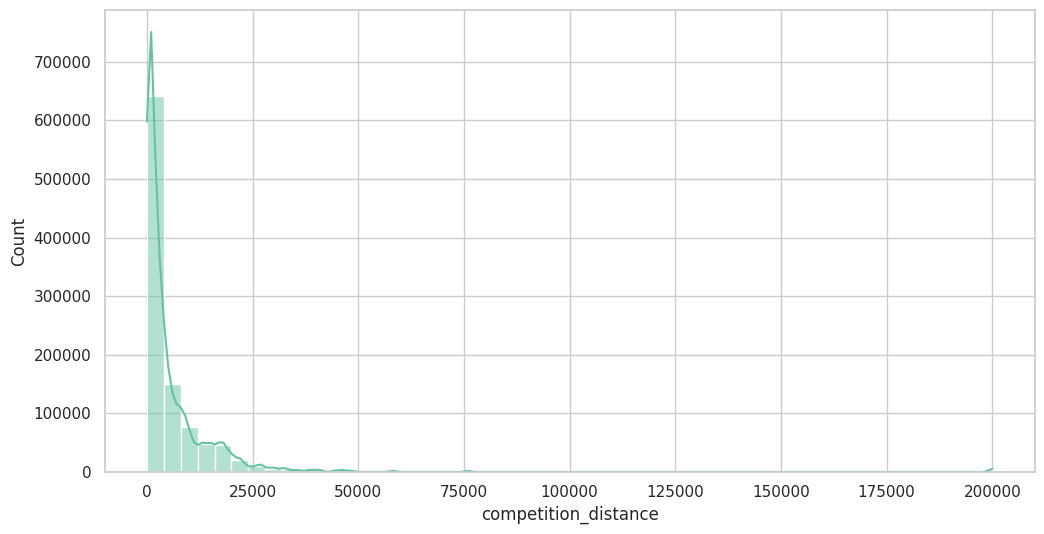

In [28]:
sns.histplot(df1['competition_distance'], kde=True, bins = 50)

plt.show()


## Variáveis Categóricas

In [29]:
cat_attributes.nunique()

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

<Axes: xlabel='assortment', ylabel='sales'>

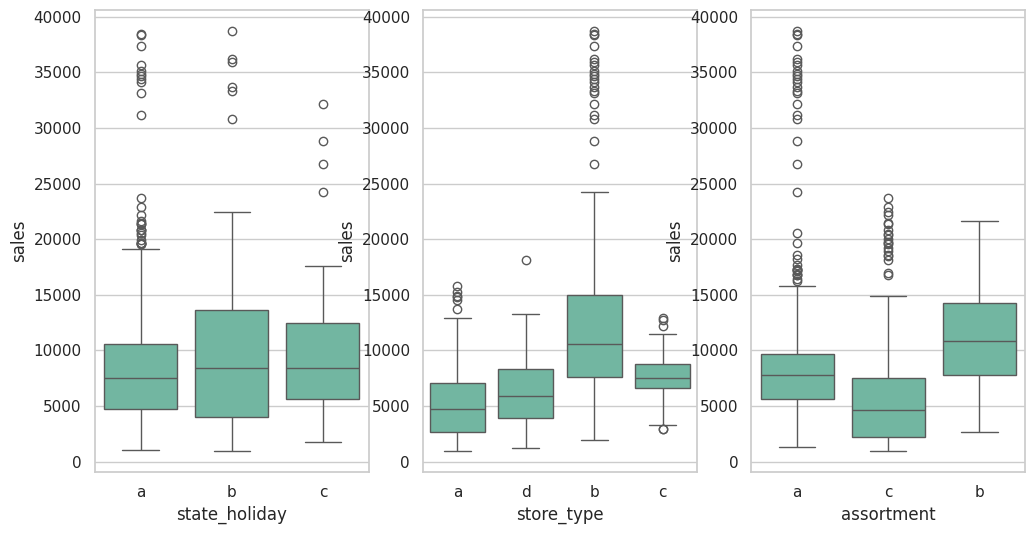

In [30]:
aux = df1[(df1['state_holiday'] != '0') & (df1['sales'] > 0)]

plt.subplot( 1, 3, 1 )
sns.boxplot( x='state_holiday', y='sales', data=aux )

plt.subplot( 1, 3, 2 )
sns.boxplot( x='store_type', y='sales', data=aux )

plt.subplot( 1, 3, 3 )
sns.boxplot( x='assortment', y='sales', data=aux )

# PASSO 2 - Feature Engineering

In [31]:
df2 = df1.copy()

In [32]:
df2['year'] = df2['date'].dt.year
df2['month'] = df2['date'].dt.month
df2['day'] = df2['date'].dt.day

df2['week_of_year'] = df2['date'].dt.isocalendar().week.astype(int)

df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

In [33]:
df2['competition_since'] = pd.to_datetime(
    dict(year=df2['competition_open_since_year'],
         month=df2['competition_open_since_month'],
         day=1)
)

df2['competition_time_month'] = (
    (df2['date'] - df2['competition_since']).dt.days / 30
).fillna(0)

df2['competition_time_month'] = df2['competition_time_month'].clip(lower=0).astype(int)

In [34]:
# promo since
df2['promo_since'] = (
    df2['promo2_since_year'].astype(str) + '-' +
    df2['promo2_since_week'].astype(str) + '-1'
)

df2['promo_since'] = pd.to_datetime(
    df2['promo_since'],
    format='%Y-%W-%w',
    errors='coerce'
)

df2['promo_time_week'] = (
    (df2['date'] - df2['promo_since']) / np.timedelta64(1, 'W')
).fillna(0).astype(int)

# assortment
df2['assortment_type'] = df2['assortment'].map({
    'a':'basic','b':'extra','c':'extended'
})

# state holiday
df2['state_holiday_desc'] = df2['state_holiday'].map({
    'a':'public_holiday',
    'b':'easter_holiday',
    'c':'christmas',
    '0':'regular_day'
})

In [35]:
# promo month
df2['month_map'] = df2['date'].dt.strftime('%b')

df2['promo_month'] = df2.apply(
    lambda x: 0 if x['promo_interval'] == 0
    else 1 if x['month_map'] in x['promo_interval']
    else 0,
axis=1
)

# is promo
df2['is_promo'] = df2['promo'] * df2['promo_month']

# competition distance log
df2['competition_distance_log'] = np.log1p(df2['competition_distance'])

# PASSO 3 - Filtragem de dados

In [36]:
df3 = df2.copy()

## Filtragem das Linhas

In [37]:
df3 = df3[(df3['open'] !=0) & (df3['sales']>0)]

## Seleção das Colunas

In [38]:
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
df3 = df3.drop( cols_drop, axis=1, errors='ignore' )

In [39]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'assortment_type', 'state_holiday_desc', 'promo_month',
       'competition_distance_log'],
      dtype='str')

# PASSO 4 - Analise Exploratória dos Dados (EDA)

## Analise Univariada

### Response Variable

<Axes: xlabel='sales', ylabel='Count'>

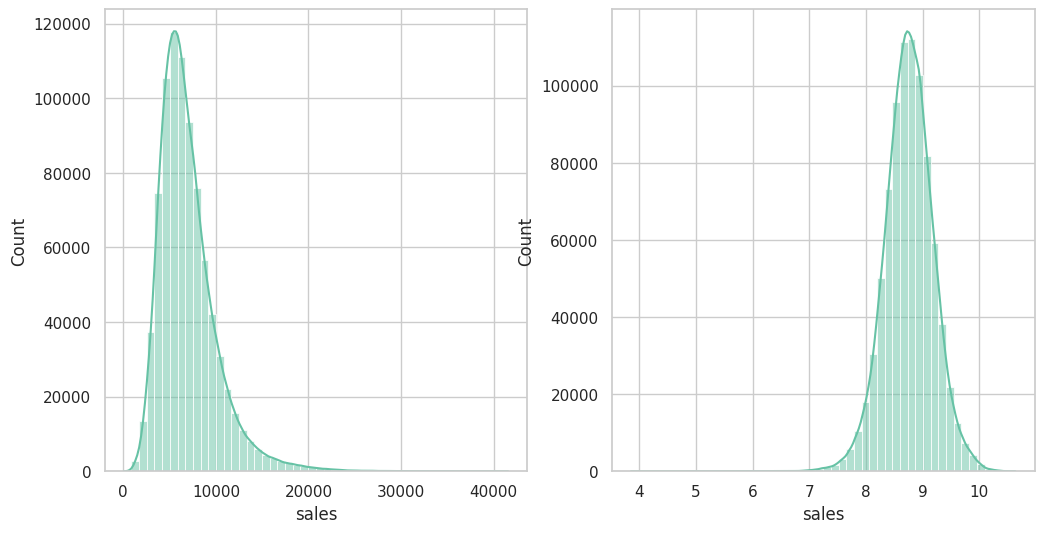

In [40]:
plt.subplot(1, 2, 1)
sns.histplot(df3['sales'], kde = True, bins = 50)

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df3['sales']), kde=True, bins = 50)

## Numerical Variable

array([[<Axes: title={'center': 'store'}>,
        <Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'sales'}>,
        <Axes: title={'center': 'customers'}>],
       [<Axes: title={'center': 'open'}>,
        <Axes: title={'center': 'promo'}>,
        <Axes: title={'center': 'school_holiday'}>,
        <Axes: title={'center': 'competition_distance'}>],
       [<Axes: title={'center': 'competition_open_since_month'}>,
        <Axes: title={'center': 'competition_open_since_year'}>,
        <Axes: title={'center': 'promo2'}>,
        <Axes: title={'center': 'promo2_since_week'}>],
       [<Axes: title={'center': 'promo2_since_year'}>,
        <Axes: title={'center': 'is_promo'}>, <Axes: >, <Axes: >]],
      dtype=object)

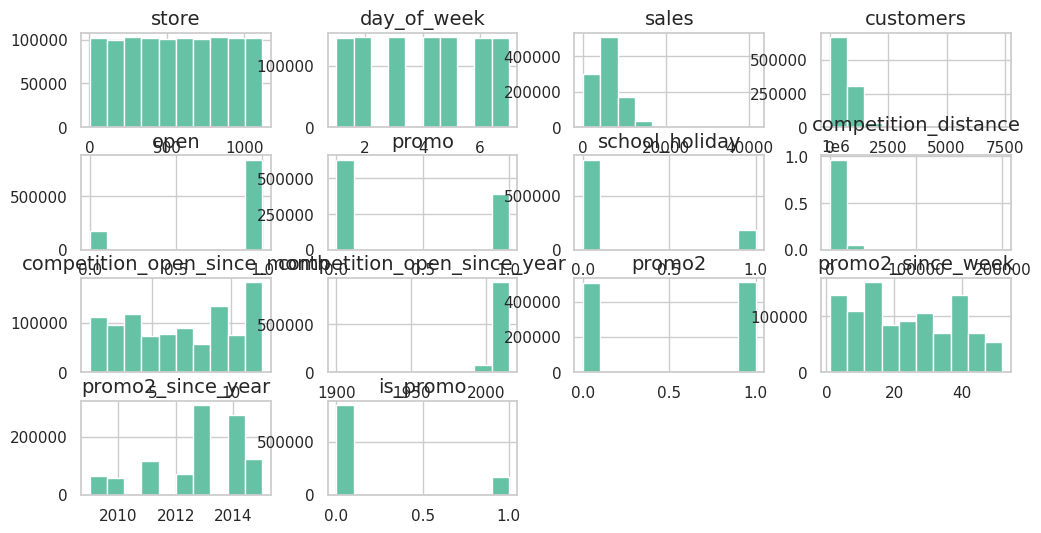

In [41]:
num_attributes.hist()

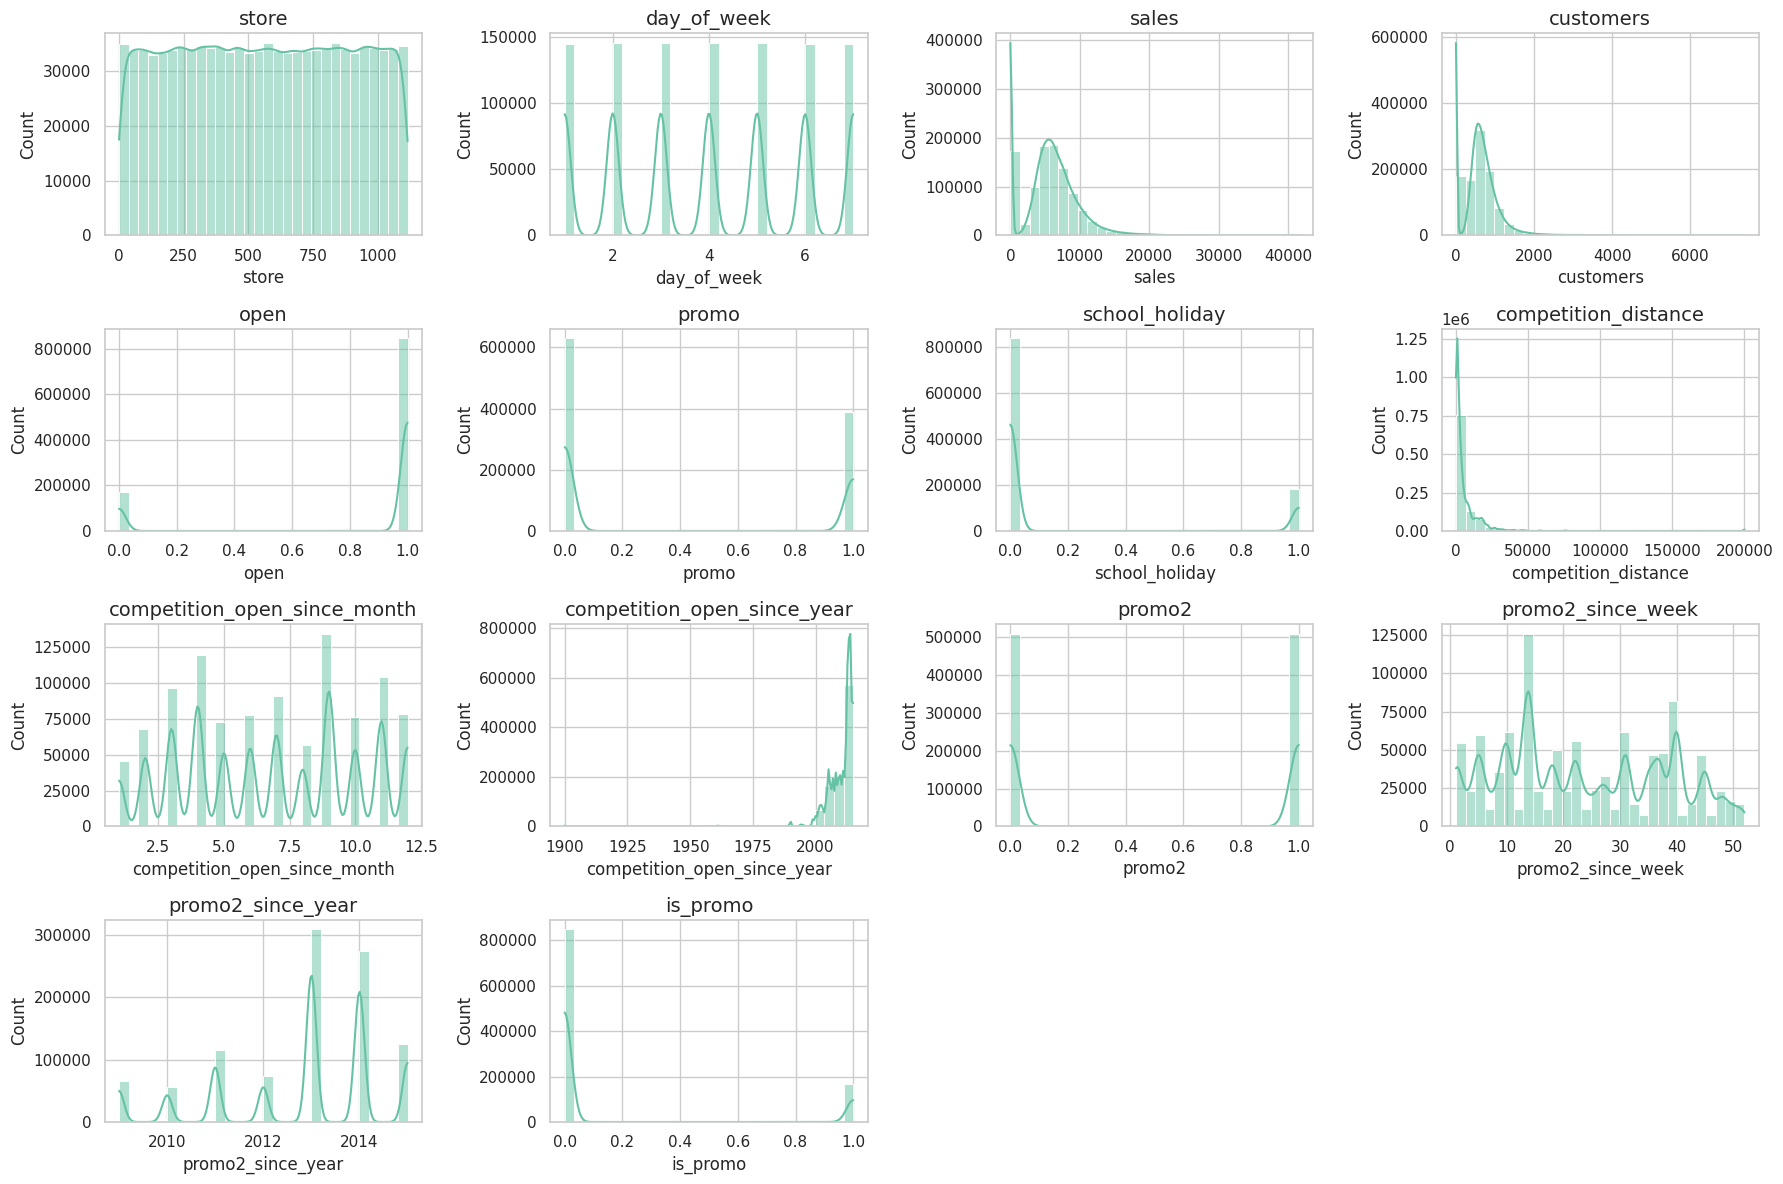

In [42]:
num_cols = num_attributes.columns

plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    
    plt.subplot(4,4,i+1)
    
    sns.histplot(
        num_attributes[col],
        bins=30,
        kde=True
    )
    
    plt.title(col)

plt.tight_layout()

## Categorical Variable

In [43]:
cat_attributes.nunique()

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

In [44]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'assortment_type', 'state_holiday_desc', 'promo_month',
       'competition_distance_log'],
      dtype='str')

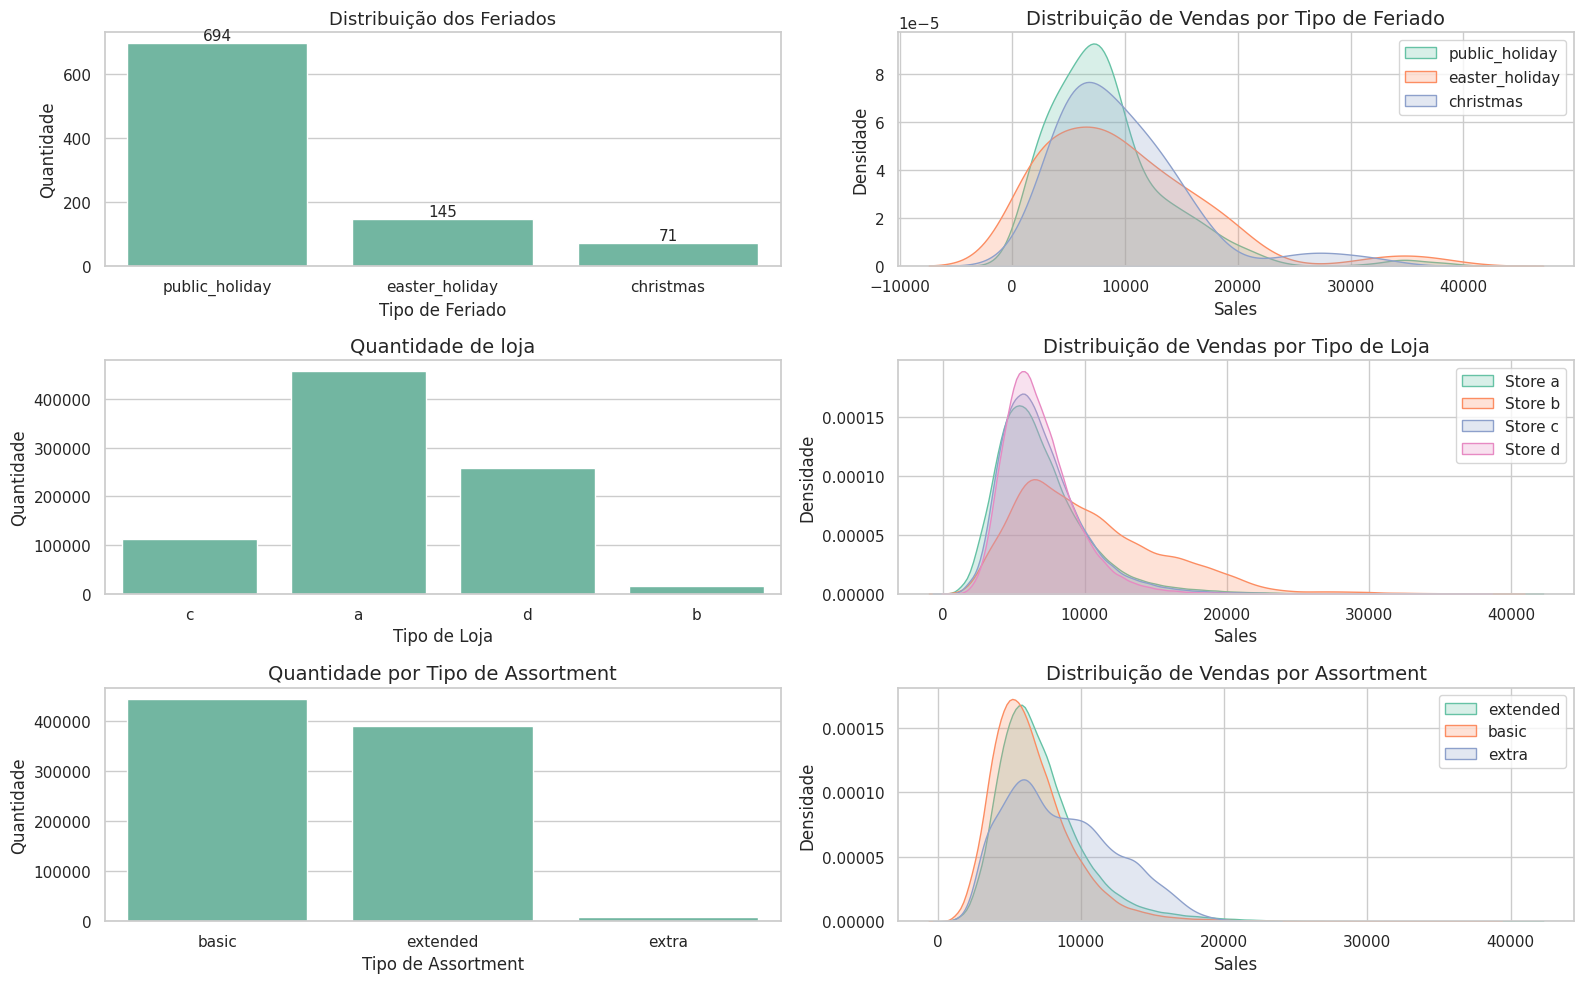

In [45]:
plt.figure(figsize=(16,10))

# -----------------------------
# gráfico 1 - distribuição de feriados
# -----------------------------
plt.subplot(3,2,1)

a = df3[df3['state_holiday_desc'] != 'regular_day']

ax = sns.countplot(
    x='state_holiday_desc',
    data=a,
    order=a['state_holiday_desc'].value_counts().index
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Distribuição dos Feriados', fontsize=13)
plt.xlabel('Tipo de Feriado')
plt.ylabel('Quantidade')


# -----------------------------
# gráfico 2 - vendas por feriado
# -----------------------------
plt.subplot(3,2,2)

for holiday in ['public_holiday','easter_holiday','christmas']:
    sns.kdeplot(
        df3[df3['state_holiday_desc']==holiday]['sales'],
        label=holiday,
        fill=True
    )

plt.title('Distribuição de Vendas por Tipo de Feriado')
plt.xlabel('Sales')
plt.ylabel('Densidade')
plt.legend()

# -----------------------------
# gráfico 3 - tipo de loja
# -----------------------------
plt.subplot(3,2,3)

sns.countplot(x='store_type', data =df3)

plt.title('Quantidade de loja')
plt.xlabel('Tipo de Loja')
plt.ylabel('Quantidade')

# -----------------------------
# gráfico 4 - vedas por tipo de loja
# -----------------------------
plt.subplot(3,2,4)

for store in ['a','b','c','d']:
    sns.kdeplot(
        df3[df3['store_type']==store]['sales'],
        label=f'Store {store}',
        fill=True
    )

plt.title('Distribuição de Vendas por Tipo de Loja')
plt.xlabel('Sales')
plt.ylabel('Densidade')
plt.legend()

# -----------------------------
# gráfico 5 - Assortment
# -----------------------------
plt.subplot(3,2,5)

sns.countplot(x='assortment_type', data=df3)

plt.title('Quantidade por Tipo de Assortment')
plt.xlabel('Tipo de Assortment')
plt.ylabel('Quantidade')

# -----------------------------
# gráfico 6 - vendas por assortment
# -----------------------------
plt.subplot(3,2,6)

for assort in ['extended', 'basic', 'extra']:
    sns.kdeplot(
        df3[df3['assortment_type'] == assort]['sales'],
        label=assort,
        fill=True
    )

plt.title('Distribuição de Vendas por Assortment')
plt.xlabel('Sales')
plt.ylabel('Densidade')
plt.legend()

plt.tight_layout()
plt.show()

## Análise Bivariada

### H1. Lojas com maior sortimento deveriam vender mais.
***Falso*** Considerando maior sortimento como extended, as vendas se assemelham com o sortimento basic.

/tmp/ipykernel_28631/2802305481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot (


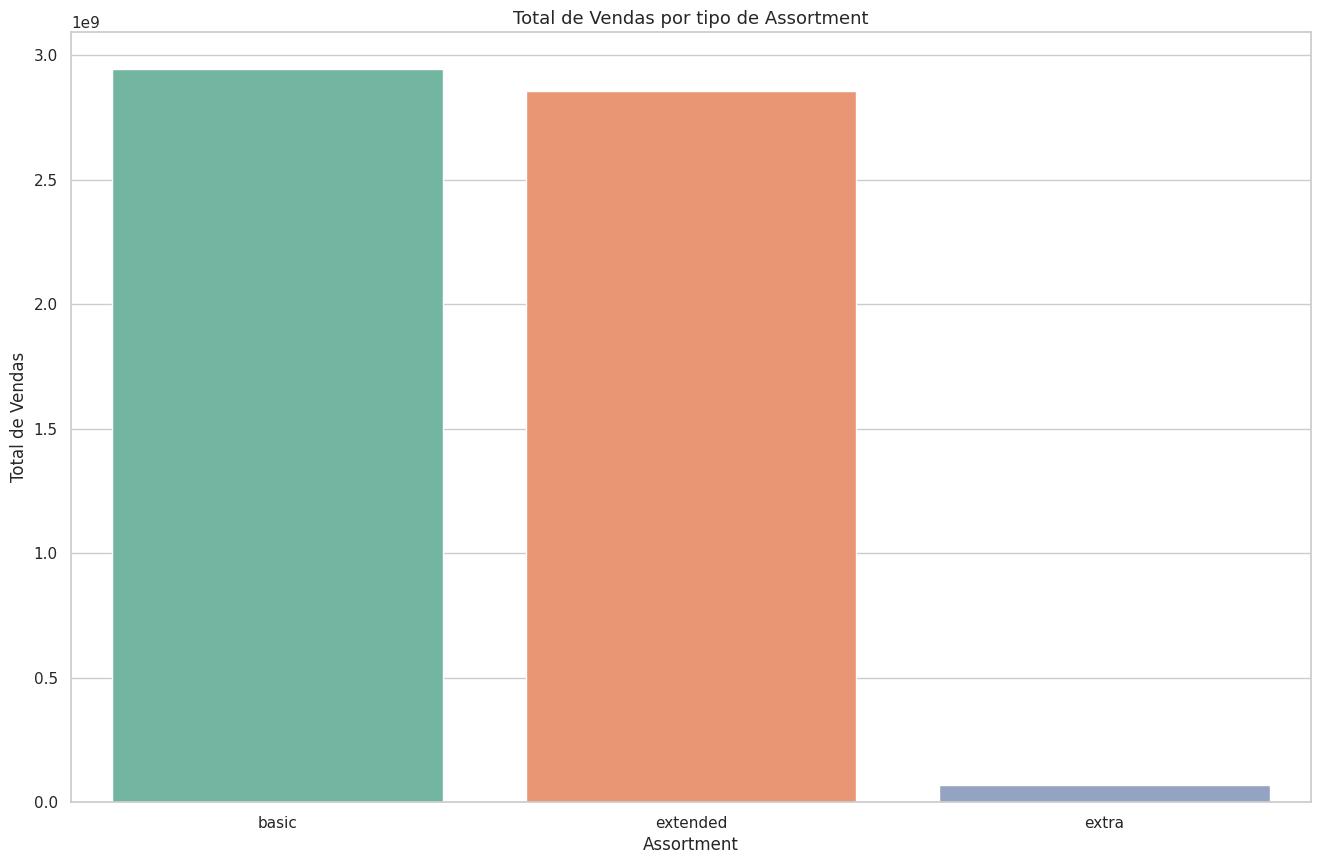

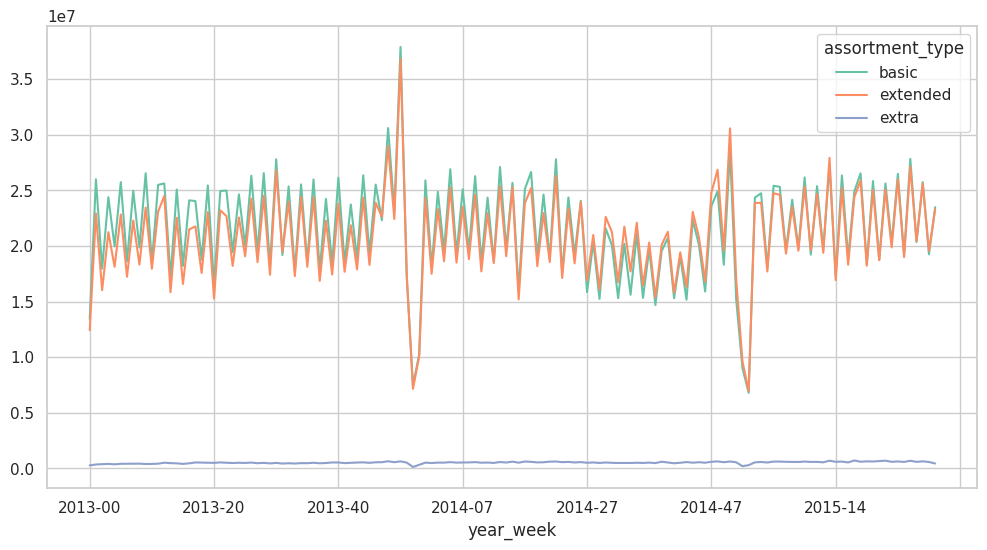

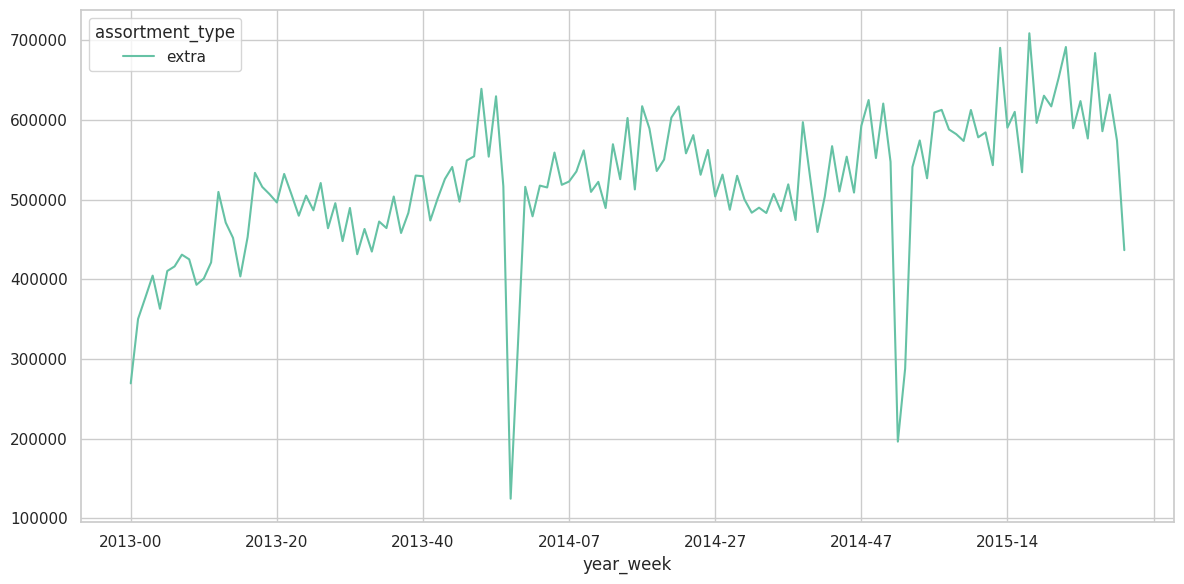

In [46]:
aux1 = df3[['assortment_type','sales']].groupby('assortment_type').sum().reset_index()

plt.figure(figsize=(16,10))

sns.barplot (
    x='assortment_type',
    y='sales',
    data=aux1,
    palette ='Set2'
);

plt.title ('Total de Vendas por tipo de Assortment', fontsize=13)
plt.xlabel ('Assortment')
plt.ylabel ('Total de Vendas')

# ------------------------
# grafico de vendas por assortment por semana do ano
# ------------------------

aux2 = df3[['assortment_type', 'year_week', 'sales']].groupby(['year_week', 'assortment_type']).sum().reset_index()
aux2.pivot(index='year_week', columns='assortment_type', values ='sales').plot()

aux3 = aux2[aux2['assortment_type']=='extra']
aux3.pivot(index='year_week', columns='assortment_type', values ='sales').plot()

plt.tight_layout()
plt.show()


In [47]:
aux2.head(5)

,year_week,assortment_type,sales
0,2013-00,basic,13434262
1,2013-00,extended,12425669
2,2013-00,extra,269404
3,2013-01,basic,26007250
4,2013-01,extended,22917693


### H2. Lojas com competidores mais próximos deveriam vender menos.
***Falso*** Quanto mais próximos os competidores, maior as vendas.

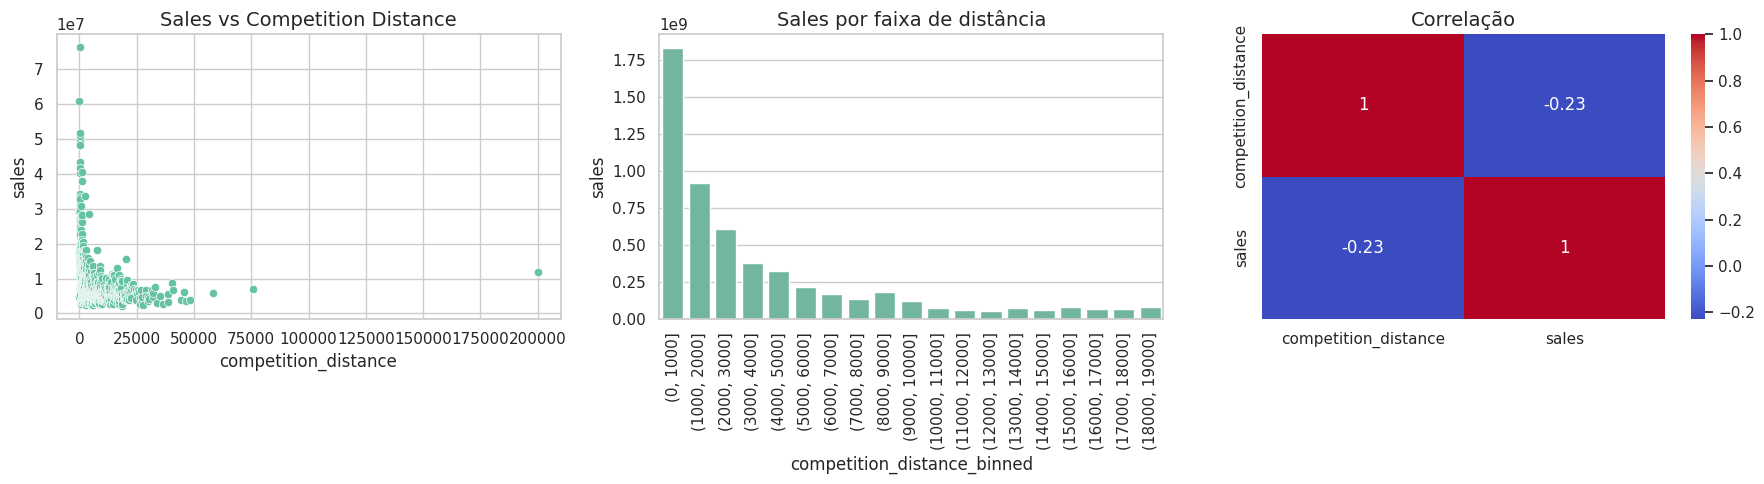

In [48]:
plt.figure(figsize=(18,5))

aux1 = df3[['competition_distance', 'sales']]\
        .groupby('competition_distance')\
        .sum()\
        .reset_index()

# -------------------------
# gráfico 1 - scatter
# -------------------------
plt.subplot(1,3,1)

sns.scatterplot(
    x='competition_distance',
    y='sales',
    data=aux1
)

plt.title('Sales vs Competition Distance')


# -------------------------
# gráfico 2 - binned
# -------------------------
plt.subplot(1,3,2)

bins = list(np.arange(0, 20000, 1000))

aux1['competition_distance_binned'] = pd.cut(
    aux1['competition_distance'],
    bins=bins
)

aux2 = aux1[['competition_distance_binned', 'sales']]\
        .groupby('competition_distance_binned')\
        .sum()\
        .reset_index()

sns.barplot(
    x='competition_distance_binned',
    y='sales',
    data=aux2
)

plt.xticks(rotation=90)
plt.title('Sales por faixa de distância')


# -------------------------
# gráfico 3 - correlação
# -------------------------
plt.subplot(1,3,3)

sns.heatmap(
    aux1[['competition_distance','sales']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlação')

plt.tight_layout()
plt.show()

In [49]:
# plt.figure(figsize=(8,6))

# sns.kdeplot(
#     data=df3,
#     x='competition_distance_log',
#     y='sales',
#     cmap='viridis',
#     fill=True
# )

### H3. Lojas com competidores a mais tempo deveriam vender mais.
***Falso*** Lojas com competidores a mais tempo vendem menos

<Axes: >

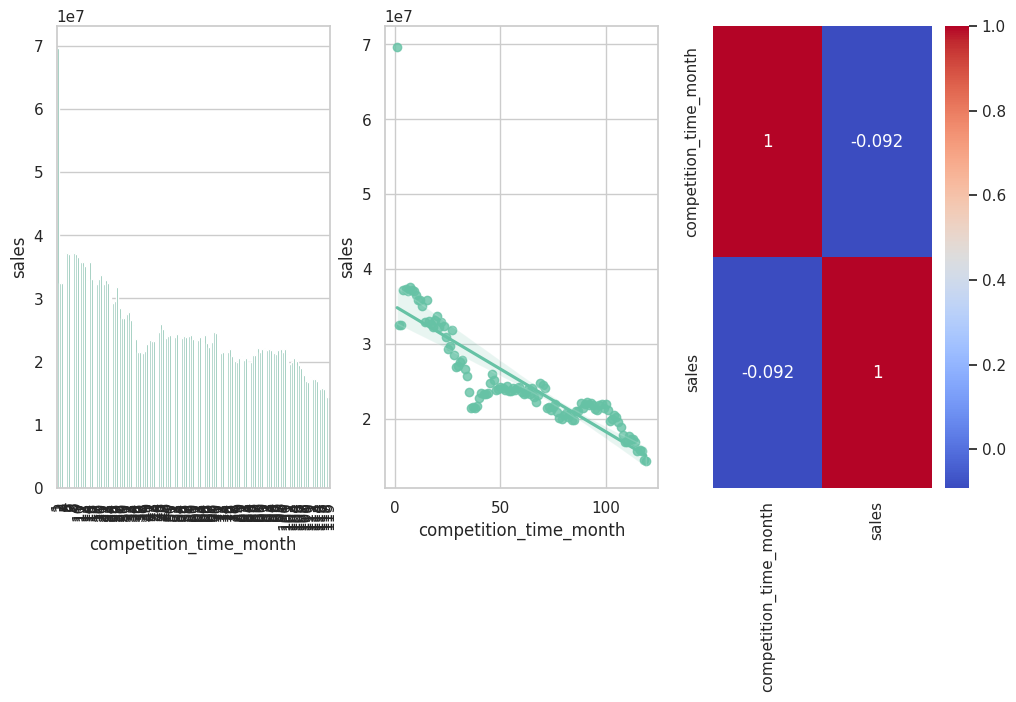

In [50]:
plt.subplot(1, 3, 1)
aux1 = df3[['competition_time_month', 'sales']].groupby('competition_time_month').sum().reset_index()
aux2 = aux1[(aux1['competition_time_month'] < 120) & (aux1['competition_time_month'] != 0)]

sns.barplot(x='competition_time_month', y='sales', data=aux2)
plt.xticks(rotation=90)

plt.subplot(1, 3, 2)
sns.regplot(x='competition_time_month', y='sales', data=aux2)

plt.subplot(1,3,3)

sns.heatmap(
    aux1[['competition_time_month','sales']].corr(),
    annot=True,
    cmap='coolwarm'
)

In [51]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'assortment_type', 'state_holiday_desc', 'promo_month',
       'competition_distance_log'],
      dtype='str')

### H4. Lojas com promoções ativas por mais tempo deveriam vender mais
***Falso*** Lojas com promocoes ativas por mais tempo vendem menos, depois de um certo periodo de promocao

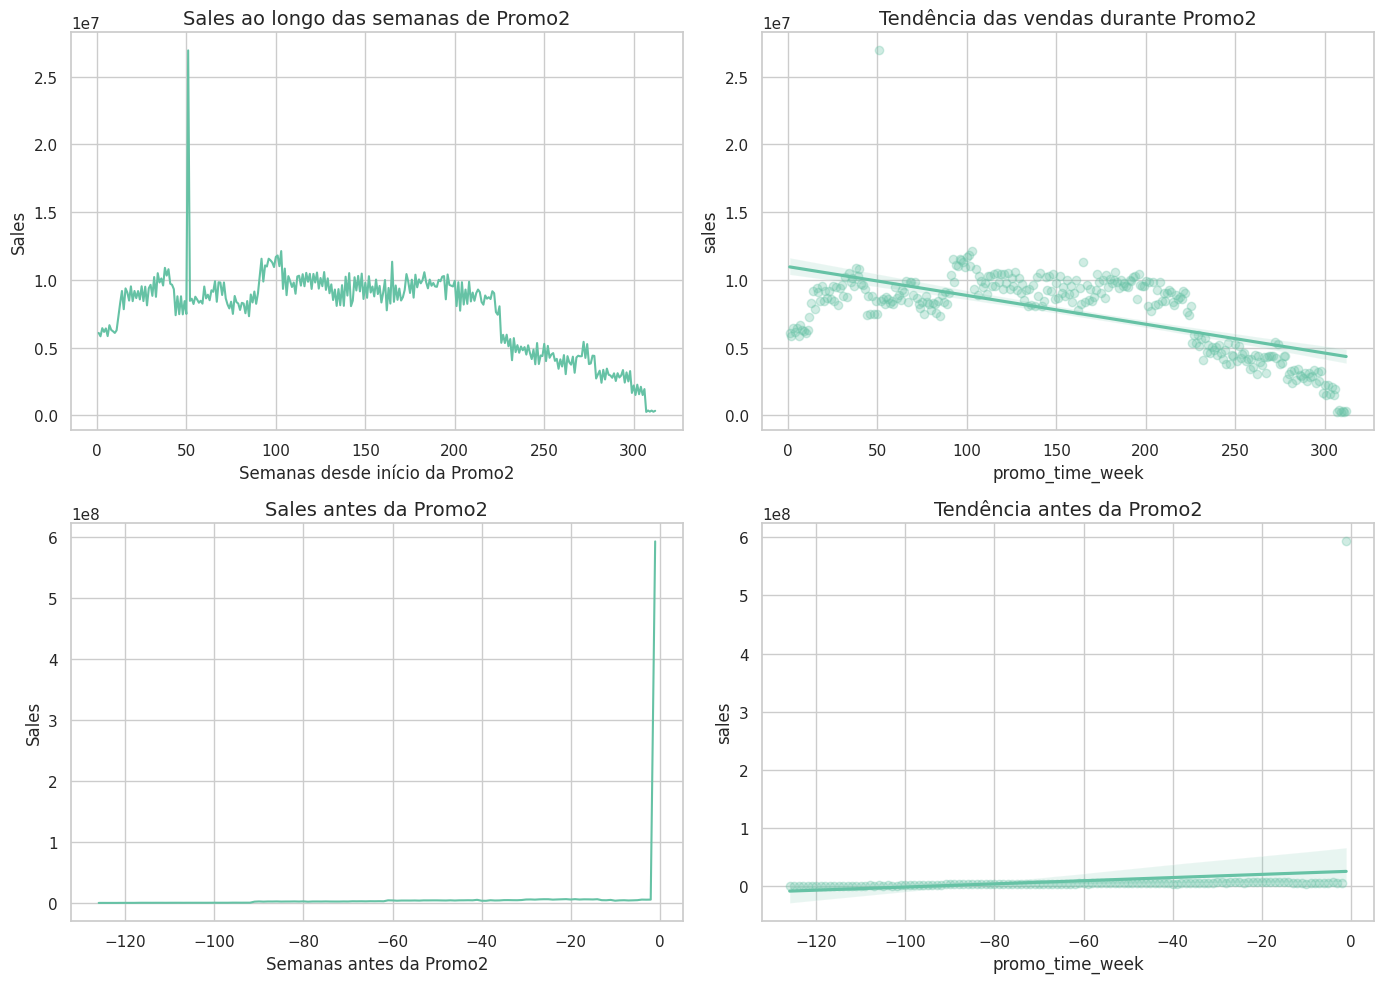

In [52]:
# agregação
aux1 = (
    df3[['promo_time_week', 'sales']]
    .groupby('promo_time_week')
    .sum()
    .reset_index()
)

# separar promoções
aux2 = aux1[aux1['promo_time_week'] > 0]   # promo2 ativa
aux3 = aux1[aux1['promo_time_week'] < 0]   # antes da promo2

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# -------------------------
# promo ativa
# -------------------------
sns.lineplot(
    data=aux2,
    x='promo_time_week',
    y='sales',
    ax=axes[0,0]
)

axes[0,0].set_title('Sales ao longo das semanas de Promo2')
axes[0,0].set_xlabel('Semanas desde início da Promo2')
axes[0,0].set_ylabel('Sales')


sns.regplot(
    data=aux2,
    x='promo_time_week',
    y='sales',
    scatter_kws={'alpha':0.3},
    ax=axes[0,1]
)

axes[0,1].set_title('Tendência das vendas durante Promo2')


# -------------------------
# antes da promo
# -------------------------
sns.lineplot(
    data=aux3,
    x='promo_time_week',
    y='sales',
    ax=axes[1,0]
)

axes[1,0].set_title('Sales antes da Promo2')
axes[1,0].set_xlabel('Semanas antes da Promo2')
axes[1,0].set_ylabel('Sales')


sns.regplot(
    data=aux3,
    x='promo_time_week',
    y='sales',
    scatter_kws={'alpha':0.3},
    ax=axes[1,1]
)

axes[1,1].set_title('Tendência antes da Promo2')


plt.tight_layout()
plt.show()

In [53]:
df3[df3['promo_time_week'].between(-2,2)].sort_values('sales', ascending=False)

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,assortment_type,state_holiday_desc,promo_month,competition_distance_log
132946,262,5,2015-04-03,38722,1,b,0,b,a,1180.0,5,2013,0,14,2015,0,2015,4,3,14,2015-13,2013-05-01,23,2015-04-06,0,basic,easter_holiday,0,7.074117
101726,262,5,2015-05-01,38484,1,a,0,b,a,1180.0,5,2013,0,18,2015,0,2015,5,1,18,2015-17,2013-05-01,24,2015-05-04,0,basic,public_holiday,0,7.074117
87231,262,4,2015-05-14,38367,0,a,1,b,a,1180.0,5,2013,0,20,2015,0,2015,5,14,20,2015-19,2013-05-01,24,2015-05-18,0,basic,public_holiday,0,7.074117
424086,57,1,2014-06-16,38037,1,0,0,d,c,420.0,6,2014,0,25,2014,0,2014,6,16,25,2014-24,2014-06-01,0,2014-06-23,-1,extended,regular_day,0,6.042633
627776,817,1,2013-12-16,38025,1,0,0,a,a,140.0,3,2006,0,51,2013,0,2013,12,16,51,2013-50,2006-03-01,94,2013-12-23,-1,basic,regular_day,0,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752014,175,1,2013-08-26,316,1,0,0,c,a,4130.0,8,2013,0,35,2013,0,2013,8,26,35,2013-34,2013-08-01,0,2013-09-02,-1,basic,regular_day,0,8.326275
941137,863,7,2013-03-10,286,0,0,0,a,c,21370.0,11,2010,0,10,2013,0,2013,3,10,10,2013-09,2010-11-01,28,2013-03-11,0,extended,regular_day,0,9.969790
846592,1093,1,2013-06-03,133,1,0,0,c,c,10450.0,6,2009,0,23,2013,0,2013,6,3,23,2013-22,2009-06-01,48,2013-06-10,-1,extended,regular_day,0,9.254453
202712,898,6,2015-01-31,124,0,0,0,a,a,18540.0,1,2015,0,5,2015,0,2015,1,31,5,2015-04,2015-01-01,1,2015-02-02,0,basic,regular_day,0,9.827740


Text(0.5, 1.0, 'Impacto da Promo2 nas vendas')

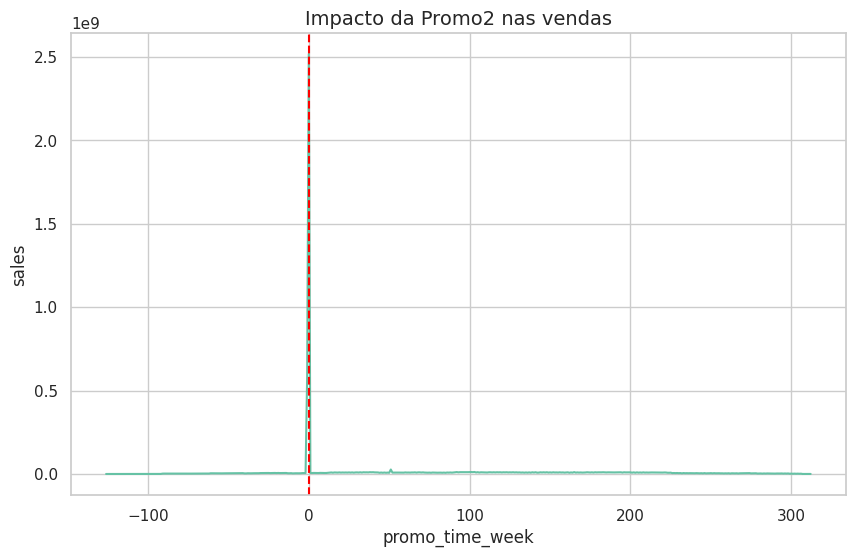

In [54]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=aux1,
    x='promo_time_week',
    y='sales'
)

plt.axvline(0, color='red', linestyle='--')
plt.title('Impacto da Promo2 nas vendas')

### H6. Lojas com mais promoções consecutivas deveriam vender mais.
***Falso*** Lojas 

In [55]:
df3[['promo', 'promo2', 'sales']].groupby( ['promo', 'promo2'] ).sum().reset_index()

,promo,promo2,sales
0,0,0,1482612096
1,0,1,1289362241
2,1,0,1628930532
3,1,1,1472275754


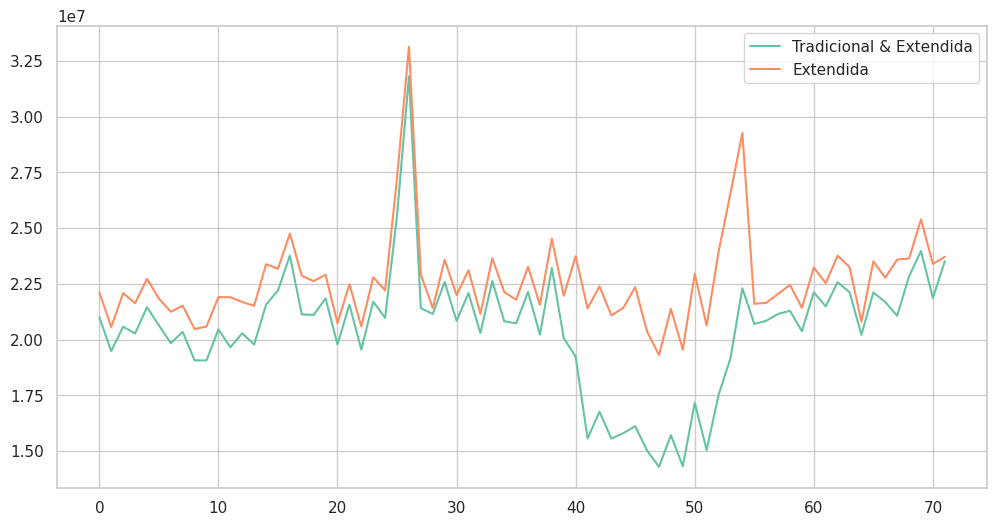

In [56]:
aux1 = df3[( df3['promo'] == 1 ) & ( df3['promo2'] == 1 )][['year_week', 'sales']].groupby( 'year_week' ).sum().reset_index()
ax = aux1.plot()

aux2 = df3[( df3['promo'] == 1 ) & ( df3['promo2'] == 0 )][['year_week','sales']].groupby( 'year_week' ).sum().reset_index()
aux2.plot( ax=ax )

ax.legend( labels=['Tradicional & Extendida', 'Extendida']);

## H8. Lojas abertas durante o feriado de natal deveriam verdar menos.
***Falso*** Lojas abertas no feriado vendem mais, em termos médios, do que dia regular, similar ao easter holiday

In [57]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'assortment_type', 'state_holiday_desc', 'promo_month',
       'competition_distance_log'],
      dtype='str')

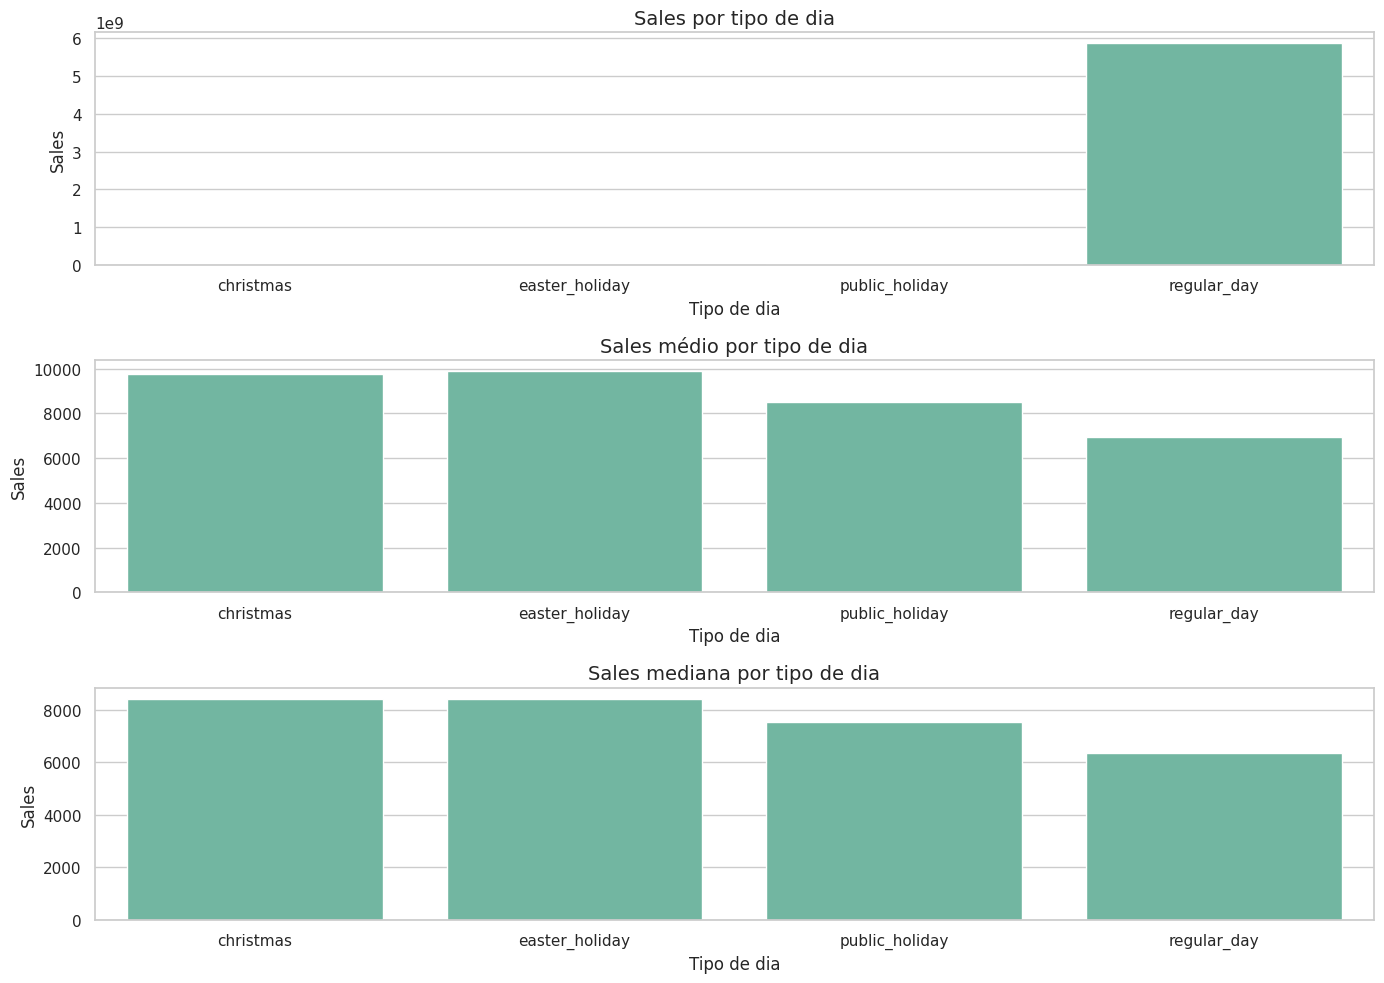

In [58]:
aux = df3[['state_holiday_desc', 'sales']].groupby('state_holiday_desc').sum().reset_index()

aux1 = df3[['state_holiday_desc', 'sales']].groupby('state_holiday_desc').mean().reset_index()

aux2 = df3[['state_holiday_desc', 'sales']].groupby('state_holiday_desc').median().reset_index()

fig, axes = plt.subplots(3, figsize=(14,10))

# -------------------------
# somatório de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux,
    x='state_holiday_desc',
    y='sales',
    ax=axes[0]
)

axes[0].set_title('Sales por tipo de dia')
axes[0].set_xlabel('Tipo de dia')
axes[0].set_ylabel('Sales')

# -------------------------
# média de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux1,
    x='state_holiday_desc',
    y='sales',
    ax=axes[1]
)

axes[1].set_title('Sales médio por tipo de dia')
axes[1].set_xlabel('Tipo de dia')
axes[1].set_ylabel('Sales')


# -------------------------
# média de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux2,
    x='state_holiday_desc',
    y='sales',
    ax=axes[2]
)

axes[2].set_title('Sales mediana por tipo de dia')
axes[2].set_xlabel('Tipo de dia')
axes[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

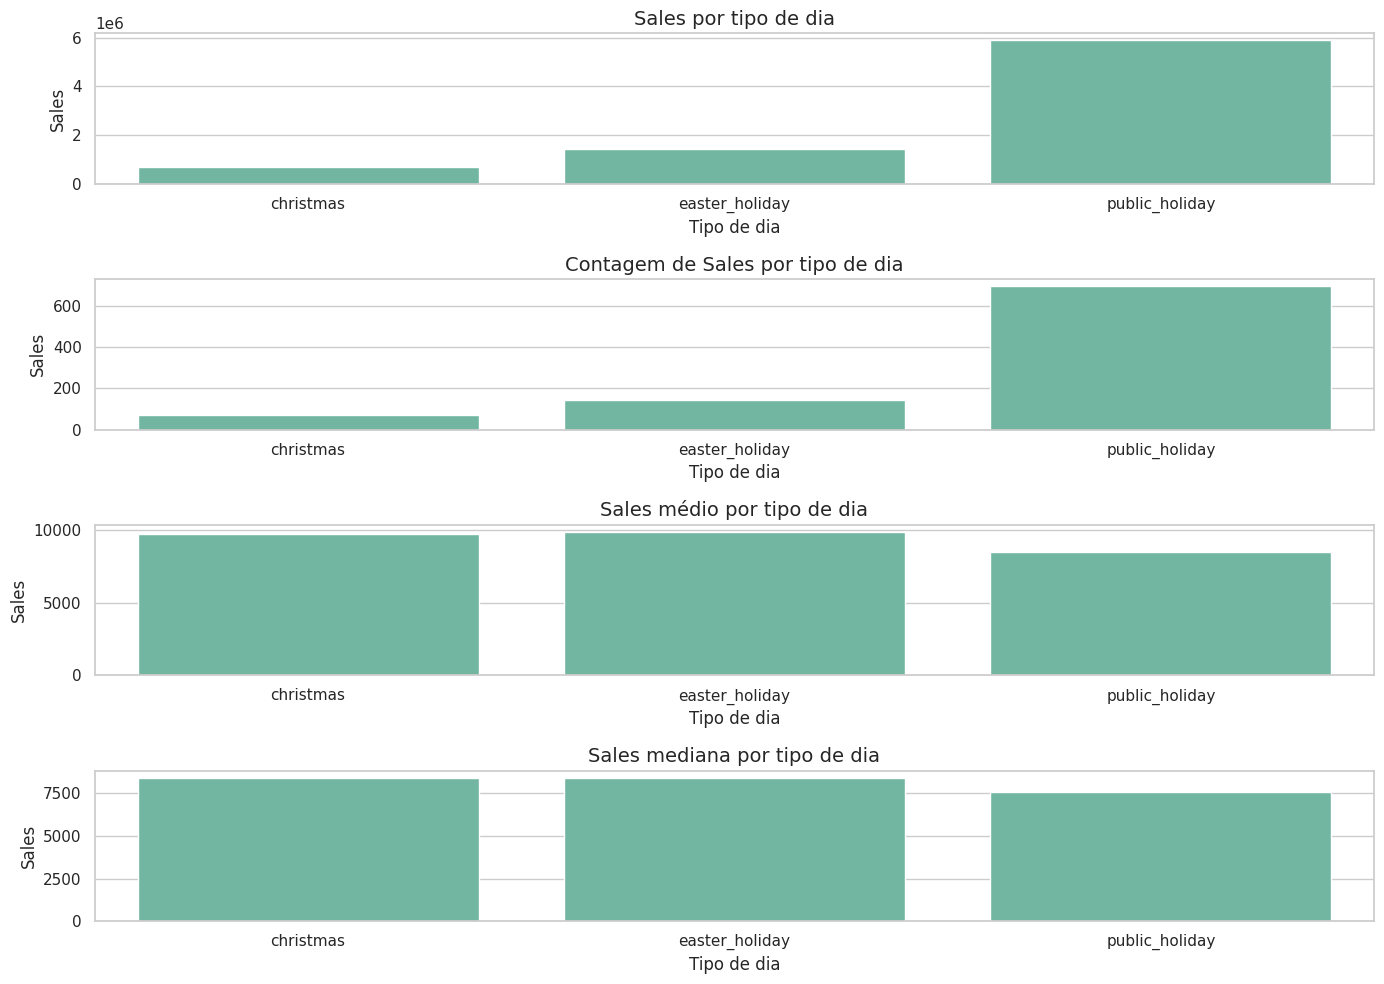

In [59]:
aux = (
    df3[df3['state_holiday_desc'] != 'regular_day']
    .groupby('state_holiday_desc')['sales']
    .agg(['sum','mean','median','count'])
    .reset_index()
)

fig, axes = plt.subplots(4, 1, figsize=(14,10))

# -------------------------
# somatório de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux,
    x='state_holiday_desc',
    y='sum',
    ax=axes[0]
)

axes[0].set_title('Sales por tipo de dia')
axes[0].set_xlabel('Tipo de dia')
axes[0].set_ylabel('Sales')

# -------------------------
# Contagem de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux,
    x='state_holiday_desc',
    y='count',
    ax=axes[1]
)

axes[1].set_title('Contagem de Sales por tipo de dia')
axes[1].set_xlabel('Tipo de dia')
axes[1].set_ylabel('Sales')

# -------------------------
# média de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux,
    x='state_holiday_desc',
    y='mean',
    ax=axes[2]
)

axes[2].set_title('Sales médio por tipo de dia')
axes[2].set_xlabel('Tipo de dia')
axes[2].set_ylabel('Sales')


# -------------------------
# média de vendas por tipo de dia/feriado
# -------------------------
sns.barplot(
    data=aux,
    x='state_holiday_desc',
    y='median',
    ax=axes[3]
)

axes[3].set_title('Sales mediana por tipo de dia')
axes[3].set_xlabel('Tipo de dia')
axes[3].set_ylabel('Sales')

plt.tight_layout()
plt.show()

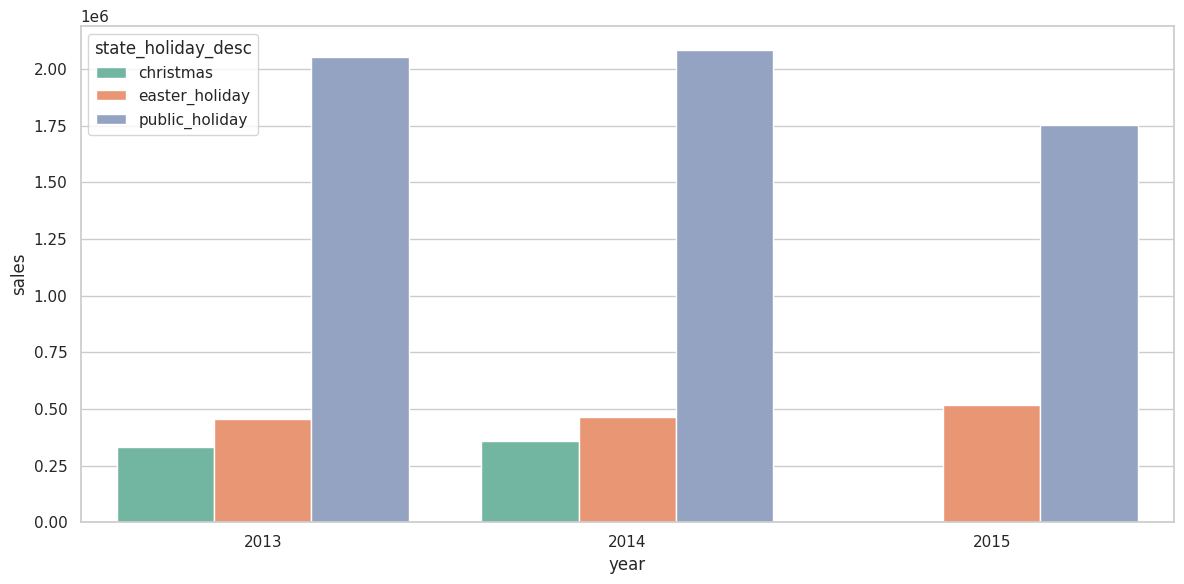

In [60]:
aux = (
    df3[df3['state_holiday_desc'] != 'regular_day']
    .groupby(['year','state_holiday_desc'])['sales']
    .sum()
    .reset_index()
)

sns.barplot(
    data=aux,
    x='year',
    y='sales',
    hue= 'state_holiday_desc'
)

plt.tight_layout()
plt.show()


## H10. Lojas deveriam vender mais no segundo semestre do ano.
***Falso*** Lojas vendem menos no segundo semestre do ano

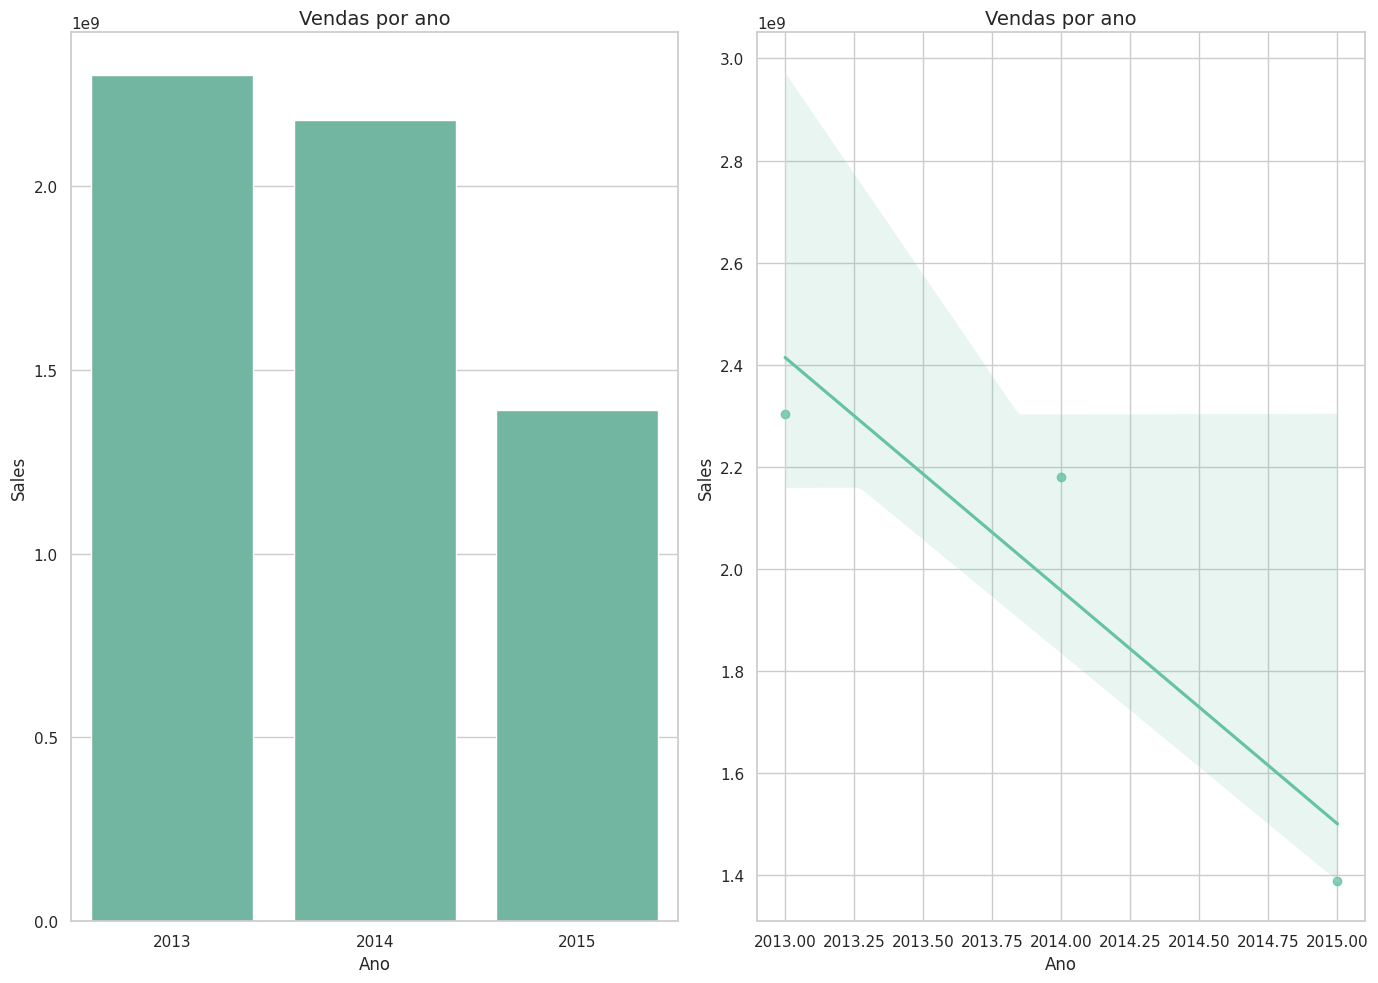

In [61]:
aux = df3[['year', 'sales']].groupby('year').sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14,10))

# -------------------------
# Vendas por ano
# -------------------------
sns.barplot(
    data=aux,
    x='year',
    y='sales',
    ax=axes[0]
)

axes[0].set_title('Vendas por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Sales')

sns.regplot(
    data=aux,
    x='year',
    y='sales',
    ax=axes[1]
)

axes[1].set_title('Vendas por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

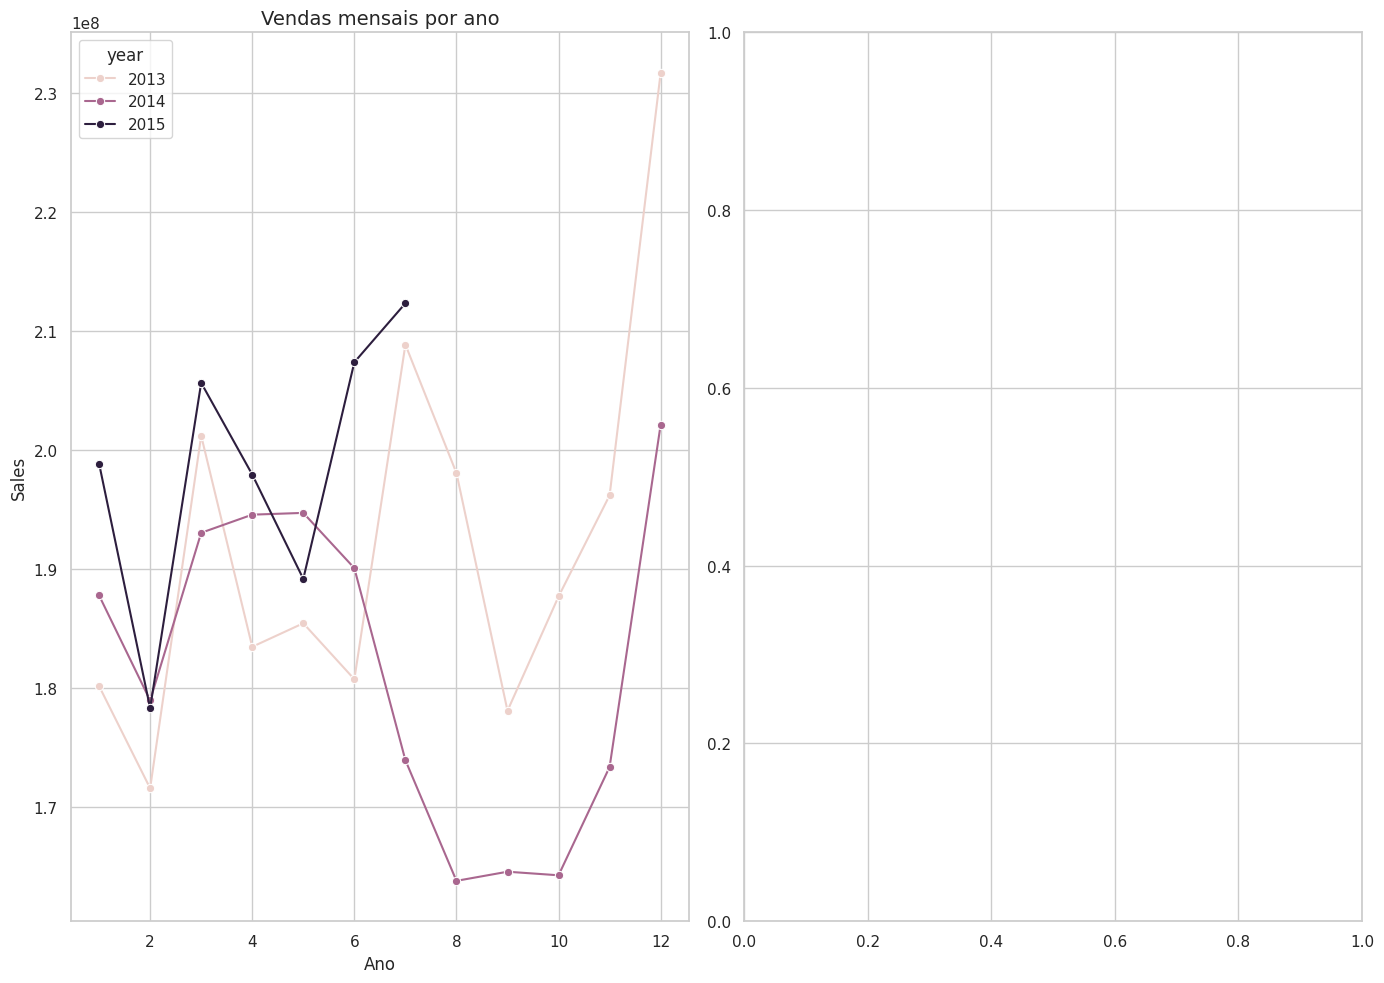

In [62]:
aux = df3.groupby(['month', 'year'])['sales'].sum().reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,10))

# -------------------------
# Vendas por ano
# -------------------------
sns.lineplot(
    data=aux,
    x='month',
    y='sales',
    hue='year',
    ax=axes[0],
    marker='o'
)

axes[0].set_title('Vendas mensais por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Sales')

plt.tight_layout()
plt.show()

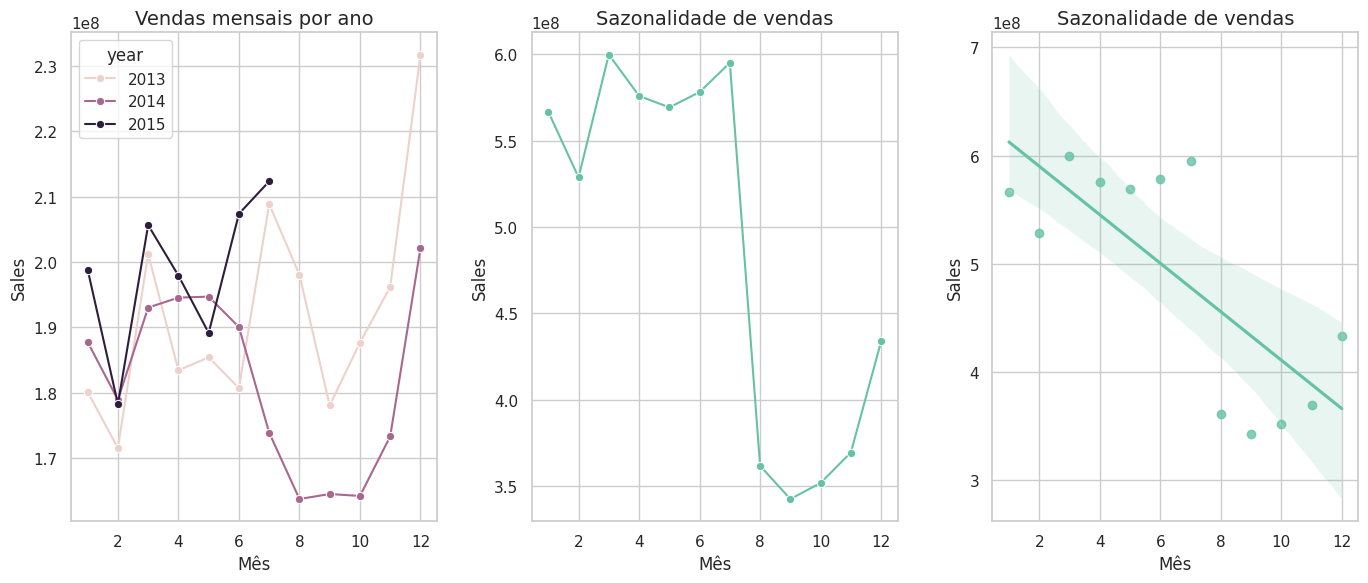

In [63]:
aux = (
    df3.groupby(['month', 'year'])['sales']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1,3, figsize=(14,6))

# -------------------------
# vendas mensais por ano
# -------------------------
sns.lineplot(
    data=aux,
    x='month',
    y='sales',
    hue='year',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Vendas mensais por ano')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Sales')


# -------------------------
# tendência geral (sem separar ano)
# -------------------------
aux2 = df3.groupby('month')['sales'].sum().reset_index()

sns.lineplot(
    data=aux2,
    x='month',
    y='sales',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Sazonalidade de vendas')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Sales')

# -------------------------
# tendência geral (sem separar ano)
# -------------------------

sns.regplot(
    data=aux2,
    x='month',
    y='sales',
    marker='o',
    ax=axes[2]
)

axes[2].set_title('Sazonalidade de vendas')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

## H11. Lojas deveriam vender mais depois do dia 10 de cada mês.
***Falso*** Lojas vendem menos depois do dia 10

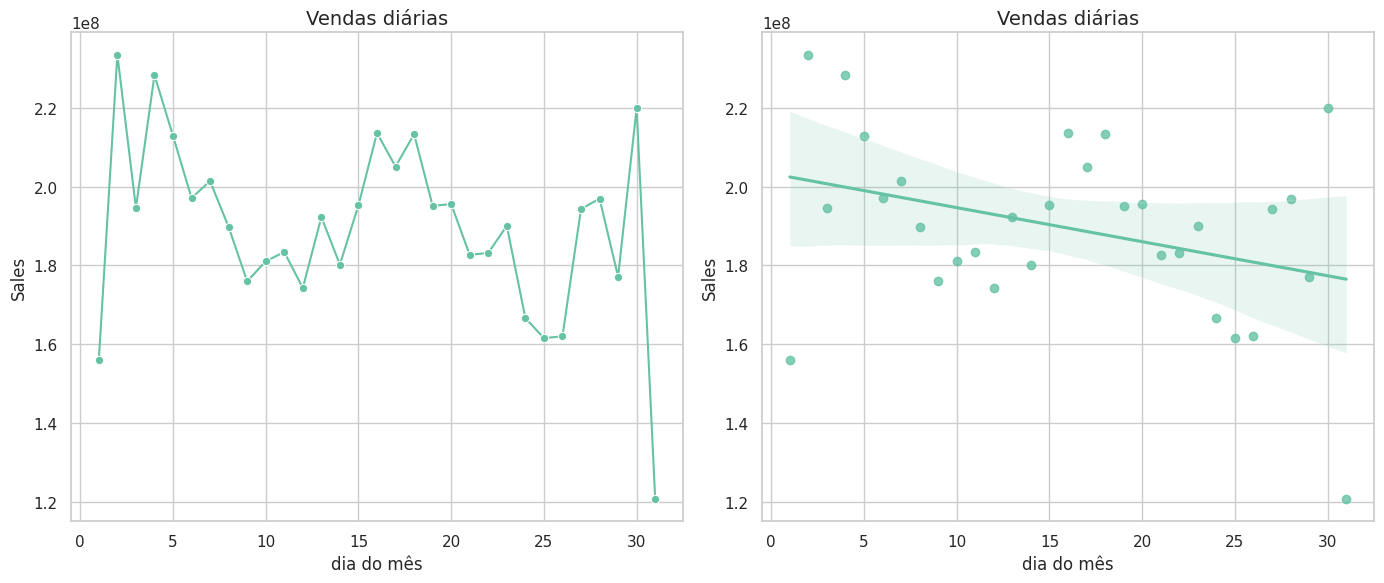

In [64]:
aux = df3.groupby('day')['sales'].sum().reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,6))

# -------------------------
# vendas por dia do mês
# -------------------------
sns.lineplot(
    data=aux,
    x='day',
    y='sales',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Vendas diárias')
axes[0].set_xlabel('dia do mês')
axes[0].set_ylabel('Sales')


sns.regplot(
    data=aux,
    x='day',
    y='sales',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Vendas diárias')
axes[1].set_xlabel('dia do mês')
axes[1].set_ylabel('Sales')



plt.tight_layout()
plt.show()



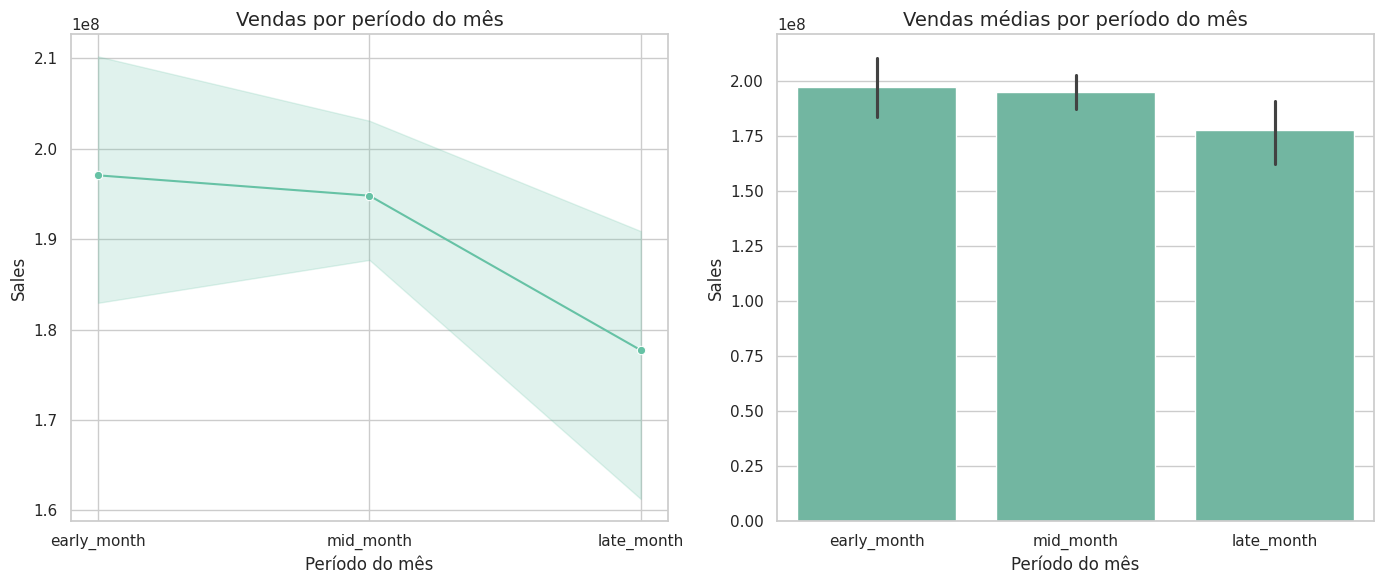

In [65]:
bins = [0,10,20,31]
labels = ['early_month','mid_month','late_month']
aux['month_period'] = pd.cut(aux['day'], bins=bins, labels=labels)

fig, axes = plt.subplots(1,2, figsize=(14,6))

# -------------------------
# vendas por período do mês
# -------------------------
sns.lineplot(
    data=aux,
    x='month_period',
    y='sales',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Vendas por período do mês')
axes[0].set_xlabel('Período do mês')
axes[0].set_ylabel('Sales')


sns.barplot(
    data=aux,
    x='month_period',
    y='sales',
    ax=axes[1]
)

axes[1].set_title('Vendas médias por período do mês')
axes[1].set_xlabel('Período do mês')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

In [66]:
aux.head(40)

,day,sales,month_period
0,1,155983560,early_month
1,2,233513169,early_month
2,3,194582812,early_month
3,4,228301010,early_month
4,5,212869176,early_month
5,6,197094539,early_month
6,7,201380487,early_month
7,8,189718770,early_month
8,9,175922427,early_month
9,10,181039363,early_month


## H12. Lojas deveriam vender menos aos finais de semana.
***Verdadeiro*** Lojas vendem menos durante os finais de semana, sobretudo no domingo.

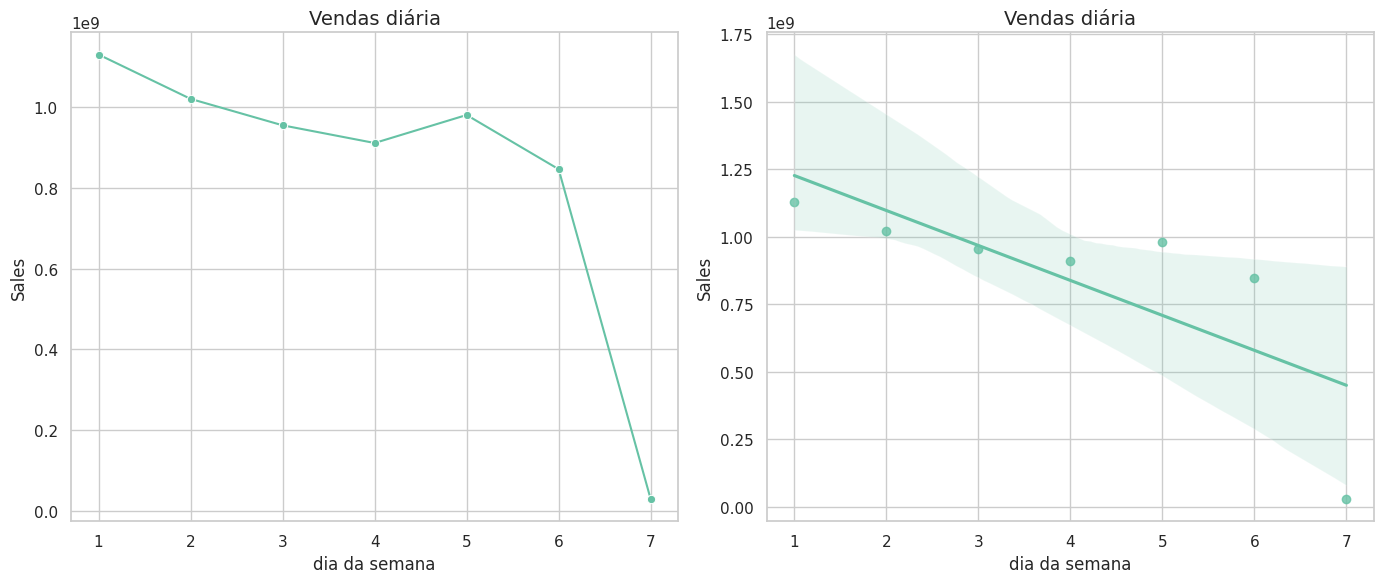

In [67]:
aux = df3.groupby('day_of_week')['sales'].sum().reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,6))

# -------------------------
# vendas por dia da semana
# -------------------------
sns.lineplot(
    data=aux,
    x='day_of_week',
    y='sales',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Vendas diária')
axes[0].set_xlabel('dia da semana')
axes[0].set_ylabel('Sales')

# -------------------------
# vendas por dia da semana
# -------------------------
sns.regplot(
    data=aux,
    x='day_of_week',
    y='sales',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Vendas diária')
axes[1].set_xlabel('dia da semana')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()


## H13. Lojas deveriam vender menos durante os feriados escolares.

***Falso*** Em termos médios e mediana as vendas aumentam levemente em comparação aos dias que não tem feriado escolar.

[]

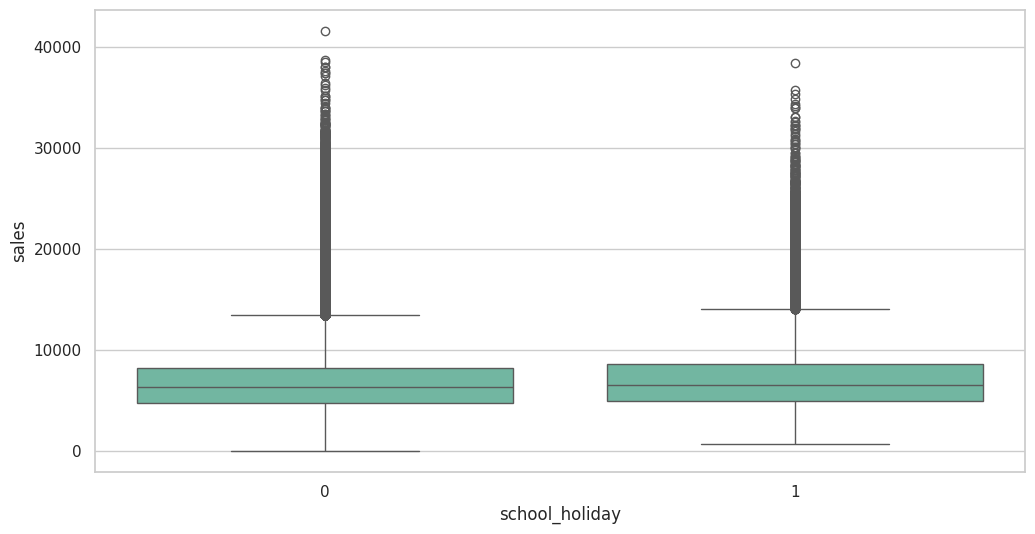

In [68]:
aux = df3[['school_holiday', 'sales']].groupby('school_holiday').mean().reset_index()

aux.head(5)

sns.boxplot(
    data=df3,
    x='school_holiday',
    y='sales'
).plot()

In [69]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'assortment_type', 'state_holiday_desc', 'promo_month',
       'competition_distance_log'],
      dtype='str')

## Resumo das Hipoteses

In [70]:
from tabulate import tabulate

ModuleNotFoundError: No module named 'tabulate'

In [ ]:
tab =[['Hipoteses', 'Conclusao', 'Relevancia'],
['H1', 'Falsa', 'Baixa'],
['H2', 'Falsa', 'Media'],
['H3', 'Falsa', 'Media'],
['H4', 'Falsa', 'Baixa'],
['H5', '-', '-'],
['H7', 'Falsa', 'Baixa'],
['H8', 'Falsa', 'Media'],
['H9', 'Falsa', 'Alta'],
['H10', 'Falsa', 'Alta'],
['H11', 'Verdadeira', 'Alta'],
['H12', 'Verdadeira', 'Alta'],
['H13', 'Verdadeira', 'Baixa'],
]
print( tabulate( tab, headers='firstrow' ) )

Hipoteses    Conclusao    Relevancia
-----------  -----------  ------------
H1           Falsa        Baixa
H2           Falsa        Media
H3           Falsa        Media
H4           Falsa        Baixa
H5           -            -
H7           Falsa        Baixa
H8           Falsa        Media
H9           Falsa        Alta
H10          Falsa        Alta
H11          Verdadeira   Alta
H12          Verdadeira   Alta
H13          Verdadeira   Baixa


## Análise Multivariada

In [ ]:
# variáveis numéricas

num_attributes_final = df3.select_dtypes(include = ['int64', 'int32', 'float64', 'datetime64[ns]'])

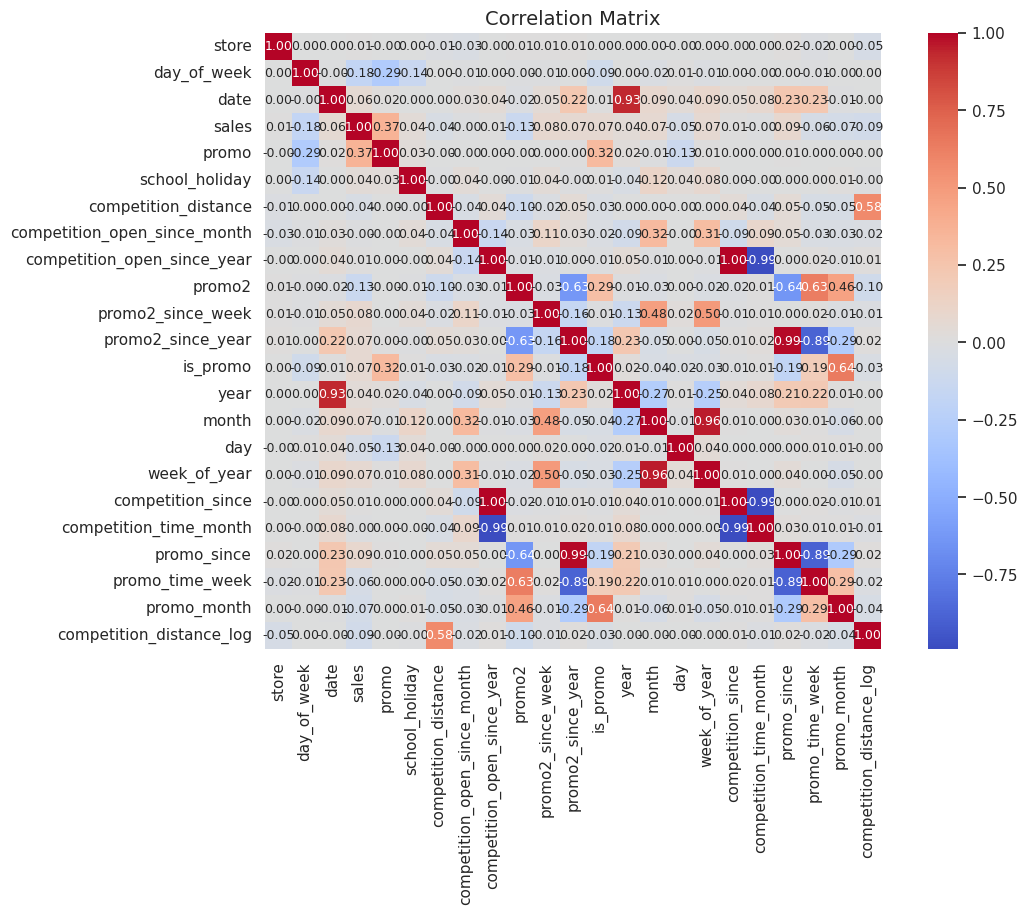

In [ ]:
correlation = num_attributes_final.corr( method='pearson' )

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    annot_kws={"size": 9}
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
# variáveis categóricas 
cat_attributes_final = df3.select_dtypes(exclude = ['int64', 'int32', 'float64', 'datetime64[ns]'])

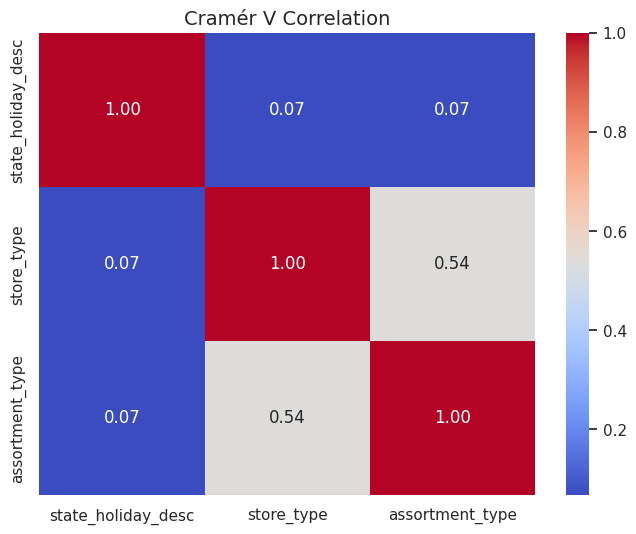

In [ ]:
# only categorical data
a = cat_attributes_final

# Calculate cramer V
a1 = cramer_v( a['state_holiday_desc'], a['state_holiday_desc'] )
a2 = cramer_v( a['state_holiday_desc'], a['store_type'] )
a3 = cramer_v( a['state_holiday_desc'], a['assortment_type'] )

a4 = cramer_v( a['store_type'], a['state_holiday_desc'] )
a5 = cramer_v( a['store_type'], a['store_type'] )
a6 = cramer_v( a['store_type'], a['assortment_type'] )

a7 = cramer_v( a['assortment_type'], a['state_holiday_desc'] )
a8 = cramer_v( a['assortment_type'], a['store_type'] )
a9 = cramer_v( a['assortment_type'], a['assortment_type'] )

# Final dataset
cols = ['state_holiday_desc', 'store_type', 'assortment_type']

d = pd.DataFrame(index=cols, columns=cols)

for i in cols:
    for j in cols:
        d.loc[i, j] = cramer_v(a[i], a[j])

d = d.astype(float)

plt.figure(figsize=(8,6))
sns.heatmap(d, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Cramér V Correlation')
plt.show()

In [ ]:
cat_attributes_final.dtypes

state_holiday         str
store_type            str
assortment            str
year_week             str
assortment_type       str
state_holiday_desc    str
dtype: object

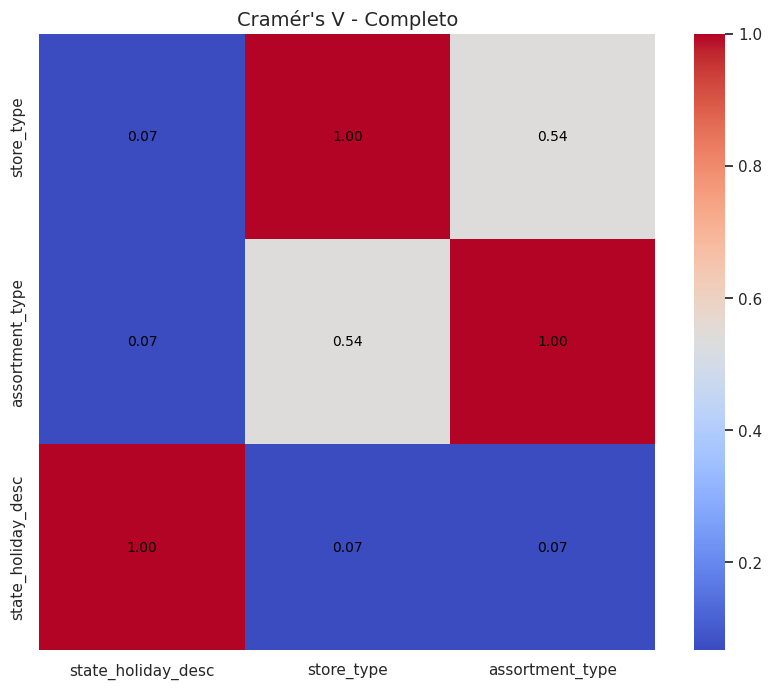

In [ ]:
# ----------------------------------------
# Seleção das variáveis categóricas
# ----------------------------------------
cols = ['state_holiday_desc', 'store_type', 'assortment_type']

a = df3[cols].copy()


# ----------------------------------------
# Matriz de Cramér's V (automática)
# ----------------------------------------
d = pd.DataFrame(index=cols, columns=cols)

for i in cols:
    for j in cols:
        d.loc[i, j] = cramer_v(a[i], a[j])

# converter para float
d = d.astype(float)


# ----------------------------------------
# (Opcional) ordenar por correlação média
# ----------------------------------------
d = d.loc[d.mean().sort_values(ascending=False).index]


# ----------------------------------------
# Plot do heatmap (estilo profissional)
# ----------------------------------------
plt.figure(figsize=(10,8))

sns.heatmap(
    d.astype(float),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    annot_kws={"size": 10, "color": "black"}
)

plt.title("Cramér's V - Completo")
plt.show()

# Passo 5 - Data Preparation

In [79]:
df4 = df3.copy()

## 5.1 Normalization

## 5.2 Rescaling

In [80]:
rs = RobustScaler()
mms = MinMaxScaler()


# competition distance
df4['competition_distance'] = rs.fit_transform( df4[['competition_distance']].values )

pickle.dump(rs,open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/competition_distance_scaler.pkl', 'wb' ))

# competition time month
df4['competition_time_month'] = rs.fit_transform(df4[['competition_time_month']].values )
pickle.dump(rs,open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/competition_time_month_scaler.pkl', 'wb' ))

# promo time week
df4['promo_time_week'] = mms.fit_transform( df4[['promo_time_week']].values )
pickle.dump(mms,open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/promo_time_week_scaler.pkl', 'wb' ))

# year
df4['year'] = mms.fit_transform( df4[['year']].values )
pickle.dump(mms,open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/year_scaler.pkl', 'wb' ))

## 5.3 Transformação

### 5.3.1 Encoding

In [81]:
df4.head()

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,assortment_type,state_holiday_desc,promo_month,competition_distance_log
0,1,5,2015-07-31,5263,1,0,1,c,a,-0.170968,9,2008,0,31,2015,0,1.0,7,31,31,2015-30,2008-09-01,0.918919,2015-08-03,0.287671,basic,regular_day,0,7.147559
1,2,5,2015-07-31,6064,1,0,1,a,a,-0.283871,11,2007,1,13,2010,1,1.0,7,31,31,2015-30,2007-11-01,1.054054,2010-03-29,0.922374,basic,regular_day,1,6.347389
2,3,5,2015-07-31,8314,1,0,1,a,a,1.903226,12,2006,1,14,2011,1,1.0,7,31,31,2015-30,2006-12-01,1.202703,2011-04-04,0.801370,basic,regular_day,1,9.556126
3,4,5,2015-07-31,13995,1,0,1,c,c,-0.275806,9,2009,0,31,2015,0,1.0,7,31,31,2015-30,2009-09-01,0.743243,2015-08-03,0.287671,extended,regular_day,0,6.431331
4,5,5,2015-07-31,4822,1,0,1,a,a,4.448387,4,2015,0,31,2015,0,1.0,7,31,31,2015-30,2015-04-01,-0.162162,2015-08-03,0.287671,basic,regular_day,0,10.305982


In [82]:
# state_holiday - One Hot Encoding
df4 = pd.get_dummies( df4, prefix=['state_holiday_desc'], columns=['state_holiday'] )

# store_type - Label Encoding
le = LabelEncoder()
df4['store_type'] = le.fit_transform( df4['store_type'] )
pickle.dump(le,open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/store_type_scaler.pkl', 'wb' ))

# assortment - Ordinal Encoding
assortment_dict = {'basic': 1, 'extra': 2, 'extended': 3}
df4['assortment_type'] = df4['assortment_type'].map( assortment_dict )

### 5.3.2 Response Variable Transformation

In [83]:
df4['sales'] = np.log1p(df4['sales'])

### 5.3.3 Nature Tranformation

In [84]:
# day of week (assumindo ciclo de 7 dias)
df4['day_of_week_sin'] = np.sin(df4['day_of_week'] * (2. * np.pi / 7))
df4['day_of_week_cos'] = np.cos(df4['day_of_week'] * (2. * np.pi / 7))

# month (ciclo de 12 meses)
df4['month_sin'] = np.sin(df4['month'] * (2. * np.pi / 12))
df4['month_cos'] = np.cos(df4['month'] * (2. * np.pi / 12))

# day (usando 30 como aproximação média para os dias do mês)
df4['day_sin'] = np.sin(df4['day'] * (2. * np.pi / 30))
df4['day_cos'] = np.cos(df4['day'] * (2. * np.pi / 30))

# week of year (ciclo de 52 semanas no ano)
df4['week_of_year_sin'] = np.sin(df4['week_of_year'] * (2. * np.pi / 52))
df4['week_of_year_cos'] = np.cos(df4['week_of_year'] * (2. * np.pi / 52))

In [85]:
df4.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'school_holiday',
       'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'assortment_type', 'state_holiday_desc', 'promo_month',
       'competition_distance_log', 'state_holiday_desc_0',
       'state_holiday_desc_a', 'state_holiday_desc_b', 'state_holiday_desc_c',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'day_sin', 'day_cos', 'week_of_year_sin', 'week_of_year_cos'],
      dtype='str')

# Passo 6 -Seleção de Variáveis

In [86]:
df5 = df4.copy()

## 6.1 Split dataframe into training and test dataset 

In [87]:
cols_drop = ['week_of_year', 'day', 'month', 'day_of_week', 'promo_since', 'competition_since', 'year_week','assortment','state_holiday_desc' ]

df5 = df5.drop(cols_drop, axis=1)

In [88]:
df5.head()

,store,date,sales,promo,school_holiday,store_type,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,competition_time_month,promo_time_week,assortment_type,promo_month,competition_distance_log,state_holiday_desc_0,state_holiday_desc_a,state_holiday_desc_b,state_holiday_desc_c,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,2015-07-31,8.568646,1,1,2,-0.170968,9,2008,0,31,2015,0,1.0,0.918919,0.287671,1,0,7.147559,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
1,2,2015-07-31,8.710290,1,1,0,-0.283871,11,2007,1,13,2010,1,1.0,1.054054,0.922374,1,1,6.347389,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
2,3,2015-07-31,9.025816,1,1,0,1.903226,12,2006,1,14,2011,1,1.0,1.202703,0.801370,1,1,9.556126,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
3,4,2015-07-31,9.546527,1,1,2,-0.275806,9,2009,0,31,2015,0,1.0,0.743243,0.287671,3,0,6.431331,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
4,5,2015-07-31,8.481151,1,1,0,4.448387,4,2015,0,31,2015,0,1.0,-0.162162,0.287671,1,0,10.305982,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984


In [89]:
df5.columns

Index(['store', 'date', 'sales', 'promo', 'school_holiday', 'store_type',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'is_promo', 'year', 'competition_time_month',
       'promo_time_week', 'assortment_type', 'promo_month',
       'competition_distance_log', 'state_holiday_desc_0',
       'state_holiday_desc_a', 'state_holiday_desc_b', 'state_holiday_desc_c',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'day_sin', 'day_cos', 'week_of_year_sin', 'week_of_year_cos'],
      dtype='str')

In [90]:
# training dataset 

X_train = df5[df5['date'] < '2015-06-19']
y_train = X_train['sales']

# test dataset 

X_test = df5[df5['date'] >= '2015-06-19']
y_test = X_test['sales']

print('Training Min Date: {}'.format(X_train['date'].min()) )
print('Training Max Date: {}'.format(X_train['date'].max()) )

print('Test Min Date: {}'.format(X_test['date'].min()) )
print('Test Max Date: {}'.format(X_test['date'].max()) )

Training Min Date: 2013-01-01 00:00:00
Training Max Date: 2015-06-18 00:00:00
Test Min Date: 2015-06-19 00:00:00
Test Max Date: 2015-07-31 00:00:00


## 6.2 Boruta as feature Selector

In [91]:
## training and test dataset for Boruta
X_train_n = X_train.drop( ['date', 'sales'], axis=1 ).values
y_train_n = y_train.values.ravel()

# # define RandomForestRegressor
# rf = RandomForestRegressor( n_jobs=-1 )

# ## define Boruta
# boruta = BorutaPy( rf, n_estimators='auto', verbose=2, random_state=42 )
# boruta.fit(X_train_n, y_train_n )

In [92]:
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=5,
#     n_jobs=4,
#     random_state=42
# )

# boruta = BorutaPy(
#     rf,
#     n_estimators=100,
#     max_iter=15,
#     verbose=0,
#     random_state=42
# )

# # usar sample
# X_sample = X_train.sample(frac=0.2, random_state=42)
# y_sample = y_train.loc[X_sample.index]

# boruta.fit(
#     X_sample.drop(['date','sales'], axis=1).values,
#     y_sample.values.ravel()
# )

# boruta_features = X_train.drop(['date','sales'], axis=1).columns[boruta.support_]

### 6.2.1. Best Features from boruta

In [93]:
# X_train_fs = X_train.drop(['date', 'sales'], axis=1)

# cols_selected_boruta = X_train_fs.columns[boruta.support_].to_list()
# cols_not_selected_boruta = X_train_fs.columns[~boruta.support_].to_list()

In [94]:
# cols_selected_boruta

In [95]:
# cols_not_selected_boruta

## 6.3 LightGBM

In [96]:
# model_lgb = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     num_leaves=31,
#     random_state=42
# )

# X_train_fs = X_train.drop(['date', 'sales'], axis=1)

# model_lgb.fit(X_train_fs, y_train)

In [97]:
# importances = pd.Series(
#     model_lgb.feature_importances_,
#     index=X_train_fs.columns
# ).sort_values(ascending=False)

# print(importances.head(50))

In [98]:
# importance_ratio = importances / importances.sum()

# cumulative = importance_ratio.cumsum()

# selected_features = cumulative[cumulative <= 0.95].index.tolist()



In [99]:
selected_features = ['store', 'competition_distance', 'competition_open_since_year', 'competition_open_since_month', 'store_type', 'competition_distance_log', 'day_of_week_sin',
                       'promo2_since_week', 'assortment_type', 'promo2_since_year', 'promo_time_week', 'competition_time_month', 'promo2', 'day_of_week_cos', 'day_sin', 'day_cos', 'promo',
                       'week_of_year_cos']

In [100]:
feat_to_add = ['date', 'sales']

selected_features_full = selected_features.copy()
selected_features_full.extend(feat_to_add)

In [101]:
#cols_selected = boruta.support_.tolist()
#
## best features
#X_train_fs = X_train.drop( ['date', 'sales'], axis=1 )
#cols_selected_boruta = X_train_fs.iloc[:, cols_selected].columns.to_list()
#
## not selected boruta
#cols_not_selected_boruta = list( np.setdiff1d( X_train_fs.columns,cols_selected_boruta ) )

In [102]:
df5.head()

,store,date,sales,promo,school_holiday,store_type,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,competition_time_month,promo_time_week,assortment_type,promo_month,competition_distance_log,state_holiday_desc_0,state_holiday_desc_a,state_holiday_desc_b,state_holiday_desc_c,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,2015-07-31,8.568646,1,1,2,-0.170968,9,2008,0,31,2015,0,1.0,0.918919,0.287671,1,0,7.147559,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
1,2,2015-07-31,8.710290,1,1,0,-0.283871,11,2007,1,13,2010,1,1.0,1.054054,0.922374,1,1,6.347389,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
2,3,2015-07-31,9.025816,1,1,0,1.903226,12,2006,1,14,2011,1,1.0,1.202703,0.801370,1,1,9.556126,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
3,4,2015-07-31,9.546527,1,1,2,-0.275806,9,2009,0,31,2015,0,1.0,0.743243,0.287671,3,0,6.431331,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
4,5,2015-07-31,8.481151,1,1,0,4.448387,4,2015,0,31,2015,0,1.0,-0.162162,0.287671,1,0,10.305982,True,False,False,False,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984


In [103]:
# # Treina um modelo rápido com todas as features
# lgbm = LGBMRegressor(n_jobs=-1, random_state=42)
# lgbm.fit(X_train_n, y_train_n)

# # Cria um DataFrame com as importâncias
# df_importance = pd.DataFrame({
#     'feature': X_train.drop(['date', 'sales'], axis=1).columns,
#     'importance': lgbm.feature_importances_
# }).sort_values(by='importance', ascending=False)

# # Plota para visualização
# plt.figure(figsize=(10, 8))
# sns.barplot(x='importance', y='feature', data=df_importance)
# plt.title('Feature Importance Nativa - LightGBM')
# plt.show()

# PASSO 07 - MACHINE LEARNING MODELLING

In [104]:
x_train = X_train[selected_features]
x_test = X_test[selected_features]

# Time Series Data Preparation
x_training = X_train[selected_features_full]

# target correspondente
y_training = y_train.copy()

## 7.1 Average Model

In [105]:
aux1 = x_test.copy()
aux1['sales'] = y_test.copy()


# prediction
aux2 = aux1[['store', 'sales']].groupby( 'store' ).mean().reset_index().rename(columns={'sales': 'predictions'} )
aux1 = pd.merge( aux1, aux2, how='left', on='store' )
yhat_baseline = aux1['predictions']

# performance
baseline_result = ml_error( 'Average Model', np.expm1( y_test ), np.expm1(yhat_baseline ) )
baseline_result


,Model Name,MAE,MAPE,RMSE
0,Average Model,1354.800353,0.2064,1835.135542


## 7.2 Linear Regression Model

In [106]:
# model
lr = LinearRegression().fit( x_train, y_train )

# prediction
yhat_lr = lr.predict( x_test )

# performance
lr_result = ml_error( 'Linear Regression', np.expm1( y_test ), np.expm1(yhat_lr ) )
lr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression,1878.830243,0.297691,2659.425254


### 7.2.1 Linear Regression Model - Cross Validation

In [107]:
lr_result_cv = cross_validation(x_training, 5, 'Linear Regression', lr, verbose=False)
lr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Linear Regression,2080.28 +/- 307.57,0.3 +/- 0.01,2953.22 +/- 475.23


## 7.3 Linear Regression Regularized Model

In [108]:
# model
lrr = Lasso( alpha=0.01 ).fit( x_train, y_train )

# prediction
yhat_lrr = lrr.predict( x_test )

# performance
lrr_result = ml_error( 'Linear Regression - Lasso', np.expm1( y_test ), np.expm1( yhat_lrr ) )
lrr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression - Lasso,1896.682073,0.29093,2734.271653


### 7.3.1 Lasso - Cross Validation

In [109]:
lrr_result_cv = cross_validation(x_training, 5, 'Lasso', lrr, verbose=False)
lrr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Lasso,2118.25 +/- 341.8,0.29 +/- 0.01,3047.99 +/- 502.55


## 7.4 Random Forest Regressor

In [110]:
# model
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    max_samples=0.7,
    n_jobs=4,
    random_state=42,
    verbose=1
    )

model_rf.fit(x_train, y_train)

# prediction
yhat_rf = model_rf.predict(x_test)

# performance
rf_result = ml_error('Random Forest Regressor', np.expm1(y_test), np.expm1(yhat_rf))
rf_result

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  3.5min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,1560.764052,0.233443,2232.971054


### 7.4.1 Random Forest Regressor - Cross Validation

In [111]:
rf_result_cv = cross_validation(x_training, 5, 'Random Forest', model_rf, verbose=True)
rf_result_cv


KFold Number: 5


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.0min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  2.6min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished



KFold Number: 4


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  2.5min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished


...


KFold Number: 2


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  2.7min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished



KFold Number: 1


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  2.6min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest,1742.38 +/- 259.54,0.24 +/- 0.01,2464.56 +/- 370.58


## 7.5 XGBoost Regressor

In [112]:
# model
model_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                             eta = 0.01,
                             n_estimators = 100,
                             max_depth = 10,
                             subsample=0.7,
                             colsample_bytree=0.9).fit(x_train, y_train)

# prediction
yhat_xgb = model_xgb.predict(x_test)

# performance
xgb_result = ml_error('XGBoost Regressor', np.expm1(y_test), np.expm1(yhat_xgb))
xgb_result

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,1674.902622,0.249456,2446.733654


### 7.5.1 XGBooster Regressor - Cross Validation

In [113]:
xgb_result_cv = cross_validation(x_training, 5, 'XGBoost Regressor', model_xgb, verbose=True)
xgb_result_cv


KFold Number: 5

KFold Number: 4

KFold Number: 3

KFold Number: 2

KFold Number: 1


,Model Name,MAE CV,MAPE CV,RMSE CV
0,XGBoost Regressor,1852.73 +/- 284.75,0.25 +/- 0.01,2677.12 +/- 426.44


## 7.6 Compare Model's Performance

### 7.6.1 Single Performance

In [114]:
modelling_result = pd.concat([baseline_result, lr_result, lrr_result, rf_result, xgb_result])

modelling_result.sort_values('RMSE')

,Model Name,MAE,MAPE,RMSE
0,Average Model,1354.800353,0.206400,1835.135542
0,Random Forest Regressor,1560.764052,0.233443,2232.971054
0,XGBoost Regressor,1674.902622,0.249456,2446.733654
0,Linear Regression,1878.830243,0.297691,2659.425254
0,Linear Regression - Lasso,1896.682073,0.290930,2734.271653


### 7.6.2 Real Performance - Cross Validation

In [115]:
modelling_result_cv = pd.concat([baseline_result, lr_result_cv, lrr_result_cv, rf_result_cv, xgb_result_cv])

modelling_result_cv.sort_values('RMSE')

,Model Name,MAE,MAPE,RMSE,MAE CV,MAPE CV,RMSE CV
0,Average Model,1354.800353,0.2064,1835.135542,NaN,NaN,NaN
0,Linear Regression,NaN,NaN,NaN,2080.28 +/- 307.57,0.3 +/- 0.01,2953.22 +/- 475.23
0,Lasso,NaN,NaN,NaN,2118.25 +/- 341.8,0.29 +/- 0.01,3047.99 +/- 502.55
0,Random Forest,NaN,NaN,NaN,1742.38 +/- 259.54,0.24 +/- 0.01,2464.56 +/- 370.58
0,XGBoost Regressor,NaN,NaN,NaN,1852.73 +/- 284.75,0.25 +/- 0.01,2677.12 +/- 426.44


# Passo 8 -Hyperparameter Fine Tuning

## 8.1 Random Search

In [116]:
# param = {
#     'n_estimators': [1500, 1700, 2500, 3000, 3500],
#     'eta': [0.01, 0.03],
#     'max_depth': [3, 5, 9],
#     'subsample': [0.1, 0.5, 0.7],
#     'colsample_bytree': [0.3, 0.7, 0.9],
#     'min_child_weight': [3, 8, 15]
# }

# MAX_EVAL = 15

In [117]:
# final_result = pd.DataFrame()

# for i in range( MAX_EVAL ):
#     # sample dos hiperparâmetros
#     hp = {k: random.choice(v) for k, v in param.items()}
#     print(f'Iteração {i+1}: {hp}')

#     # modelo
#     model_xgb = xgb.XGBRegressor(
#         objective='reg:squarederror',
#         n_estimators=hp['n_estimators'],
#         eta=hp['eta'],
#         max_depth=hp['max_depth'],
#         subsample=hp['subsample'],
#         colsample_bytree=hp['colsample_bytree'],
#         min_child_weight=hp['min_child_weight'],
#         n_jobs=4,
#         random_state=42
#     )

#     # validação cruzada
#     result = cross_validation(
#         x_training,
#         5,
#         'XGBoost Regressor',
#         model_xgb,
#         verbose=True
#     )

#     result['params'] = str(hp)  # 🔥 salva os parâmetros
#     final_result = pd.concat([final_result, result], ignore_index=True)

# final_result

In [118]:
# final_result.columns = final_result.columns.str.replace(' ', '_')

# print(final_result.columns)

In [119]:
# # Escolhendo o melhor parâmetro

# best_params = final_result.sort_values('RMSE_CV').iloc[0]['params']
# print(best_params)


In [120]:
# import ast
# param_tuned = ast.literal_eval(best_params)

In [121]:
# modelo com os melhores parêmetros
model_xgb_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1500,
    eta=0.03,
    max_depth=9,
    subsample=0.7,
    colsample_bytree=0.9,
    min_child_weight=8,
    n_jobs=4,
    random_state=42
)

model_xgb_tuned.fit(x_train, y_train)

yhat_xgb_tuned = model_xgb_tuned.predict(x_test)

xgb_result_tuned = ml_error(
    'XGBoost Regressor',
    np.expm1(y_test),
    np.expm1(yhat_xgb_tuned)
)

xgb_result_tuned

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,652.878194,0.095166,949.978323


In [122]:
# model_xgb_tuned = xgb.XGBRegressor(
#     objective='reg:squarederror',
#     n_estimators=param_tuned['n_estimators'],
#     eta=param_tuned['eta'],
#     max_depth=param_tuned['max_depth'],
#     subsample=param_tuned['subsample'],
#     colsample_bytree=param_tuned['colsample_bytree'],
#     min_child_weight=param_tuned['min_child_weight'],
#     n_jobs=4,
#     random_state=42
# )

# model_xgb_tuned.fit(x_train, y_train)

# yhat_xgb_tuned = model_xgb_tuned.predict(x_test)

# xgb_result_tuned = ml_error(
#     'XGBoost Regressor',
#     np.expm1(y_test),
#     np.expm1(yhat_xgb_tuned)
# )

In [123]:
#xgb_result_tuned

## 8.2 Optuna + TimeSeriesSplit

In [124]:
# x_train_opt = x_training.copy().drop(columns=['date'])
# y_train_opt = y_train.copy()

In [125]:
# Definindo TimeSeriesSplit

# tscv = TimeSeriesSplit(n_splits=3)

In [126]:
# 3. Função objetivo

# def objective(trial):

#     params = {
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
#         'max_depth': trial.suggest_int('max_depth', 3, 6),
#         'subsample': trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
#         'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
#     }

#     rmse_list = []

#     for train_idx, val_idx in tscv.split(x_train_opt):

#         X_train_fold = x_train_opt.iloc[train_idx]
#         y_train_fold = y_train_opt.iloc[train_idx]

#         X_val_fold = x_train_opt.iloc[val_idx]
#         y_val_fold = y_train_opt.iloc[val_idx]

#         model = xgb.XGBRegressor(
#             objective='reg:squarederror',
#             n_estimators=1000,
#             early_stopping_rounds=30,   # ✅ aqui
#             eval_metric='rmse',         # ✅ obrigatório
#             n_jobs=4,
#             random_state=42,
#             **params
#         )

#         model.fit(
#             X_train_fold,
#             y_train_fold,
#             eval_set=[(X_val_fold, y_val_fold)],
#             verbose=False,            
#         )

#         y_pred = model.predict(X_val_fold)

#         rmse = np.sqrt(
#             np.mean(
#                 (np.expm1(y_val_fold) - np.expm1(y_pred)) ** 2
#             )
#         )

#         rmse_list.append(rmse)

#     return np.mean(rmse_list)

In [127]:
# rodando o optuna

# study = optuna.create_study(direction='minimize')

# study.optimize(objective, n_trials=15)

In [128]:
# melhores parâmetros

# best_params = study.best_params
# print(best_params)

In [129]:
# Modelo final

# model_xgb_final = xgb.XGBRegressor(
#     objective='reg:squarederror',
#     n_estimators=3500,
#     **best_params,
#     n_jobs=4,
#     random_state=42
# )

# model_xgb_final.fit(
#     x_train,
#     y_train,
#     eval_set=[(x_test, y_test)],    
#     verbose=True
# )

# yhat_xgb = model_xgb_final.predict(x_test)

# xgb_result = ml_error(
#     'XGBoost Tuned (Optuna)',
#     np.expm1(y_test),
#     np.expm1(yhat_xgb)
# )

# xgb_result

# Passo 9 - Tradução e Interpretação do Erro

In [130]:
df9 = X_test[selected_features_full]

# rescale
df9['sales'] = np.expm1( df9['sales'] )
df9['predictions'] = np.expm1( yhat_xgb_tuned )

In [131]:
df9.columns

Index(['store', 'competition_distance', 'competition_open_since_year',
       'competition_open_since_month', 'store_type',
       'competition_distance_log', 'day_of_week_sin', 'promo2_since_week',
       'assortment_type', 'promo2_since_year', 'promo_time_week',
       'competition_time_month', 'promo2', 'day_of_week_cos', 'day_sin',
       'day_cos', 'promo', 'week_of_year_cos', 'date', 'sales', 'predictions'],
      dtype='str')

## 9.1 Business Performance

In [132]:
# sum of predictions
df91 = df9[['store', 'predictions']].groupby( 'store' ).sum().reset_index()

# MAE and MAPE
df9_aux1 = df9[['store', 'sales', 'predictions']].groupby( 'store' ).apply( lambda x: mt.mean_absolute_error( x['sales'], x['predictions'] ) ).reset_index().rename( columns={0:'MAE'})
df9_aux2 = df9[['store', 'sales', 'predictions']].groupby( 'store' ).apply( lambda x: mt.mean_absolute_percentage_error( x['sales'], x['predictions'] ) ).reset_index().rename( columns={0:'MAPE'})

# Merge
df9_aux3 = pd.merge( df9_aux1, df9_aux2, how='inner', on='store' )
df92 = pd.merge( df91, df9_aux3, how='inner', on='store' )

# Scenarios
df92['worst_scenario'] = df92['predictions'] - df92['MAE']
df92['best_scenario'] = df92['predictions'] + df92['MAE']

# order columns
df92 = df92[['store', 'predictions', 'worst_scenario', 'best_scenario', 'MAE', 'MAPE']]


In [133]:
df92.sort_values( 'MAPE', ascending=False ).head(20)

,store,predictions,worst_scenario,best_scenario,MAE,MAPE
291,292,105529.867188,102179.157484,108880.576891,3350.709704,0.569433
908,909,238760.625000,231117.764457,246403.485543,7642.860543,0.522914
875,876,201714.250000,197807.098145,205621.401855,3907.151855,0.290273
721,722,348320.593750,346455.063859,350186.123641,1865.529891,0.254051
1065,1066,428379.312500,426270.952597,430487.672403,2108.359903,0.229830
533,534,286913.062500,285540.567277,288285.557723,1372.495223,0.218278
273,274,201325.328125,200109.677513,202540.978737,1215.650612,0.209729
930,931,155852.000000,154857.972966,156846.027034,994.027034,0.209147
549,550,231447.796875,230378.405405,232517.188345,1069.391470,0.208633
781,782,210540.296875,209815.207097,211265.386653,725.089778,0.208254


<Axes: xlabel='store', ylabel='MAPE'>

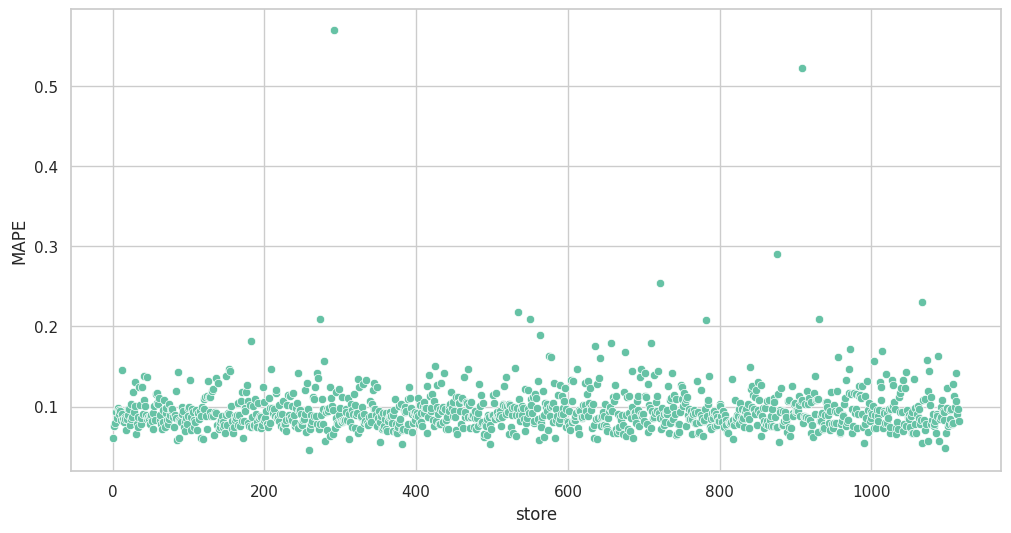

In [134]:
sns.scatterplot( x='store', y='MAPE', data=df92 )

## 9.2 Total Performance

In [135]:
df93 = df92[['predictions', 'worst_scenario', 'best_scenario']].apply( lambda x: np.sum( x ), axis=0 ).reset_index().rename( columns={'index': 'Scenario', 0:'Values'} )
df93['Values'] = df93['Values'].map( 'R${:,.2f}'.format )
df93

,Scenario,Values
0,predictions,"R$285,355,392.00"
1,worst_scenario,"R$284,623,406.75"
2,best_scenario,"R$286,087,356.34"


## 9.3 Machine Learning Performance

In [136]:
df9['error'] = df9['sales'] - df9['predictions']
df9['error_rate'] = df9['predictions'] / df9['sales']

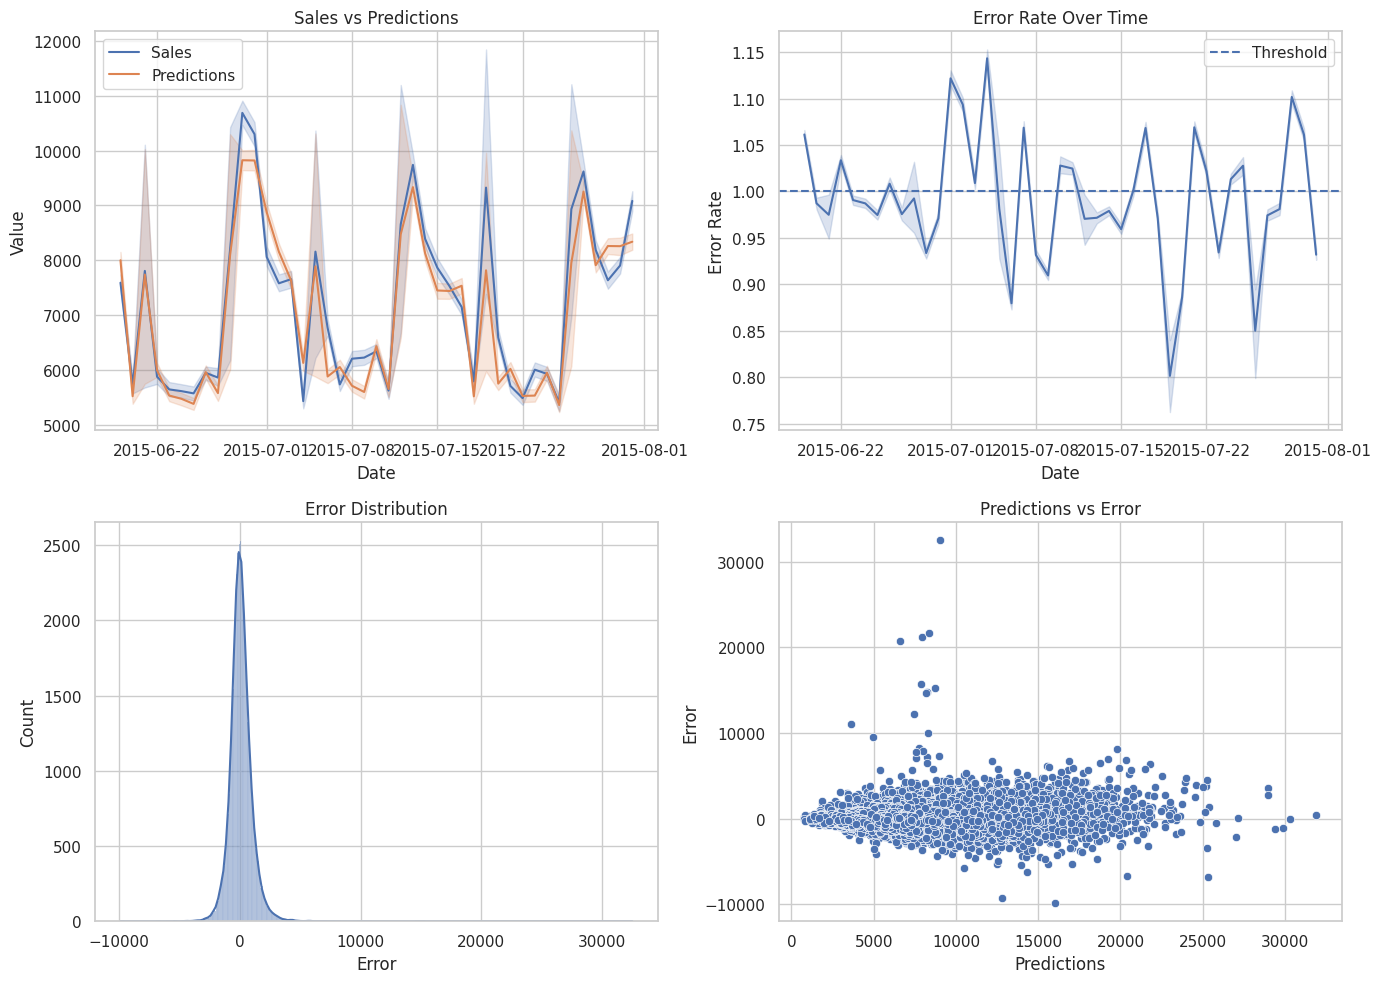

In [137]:
# Estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))

# 1. Sales vs Predictions
plt.subplot(2, 2, 1)
sns.lineplot(x='date', y='sales', data=df9, label='Sales')
sns.lineplot(x='date', y='predictions', data=df9, label='Predictions')
plt.title('Sales vs Predictions')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

# 2. Error Rate ao longo do tempo
plt.subplot(2, 2, 2)
sns.lineplot(x='date', y='error_rate', data=df9)
plt.axhline(1, linestyle='--', label='Threshold')
plt.title('Error Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Error Rate')
plt.legend()

# 3. Distribuição do erro
plt.subplot(2, 2, 3)
sns.histplot(df9['error'], kde=True)
plt.title('Error Distribution')
plt.xlabel('Error')

# 4. Predictions vs Error
plt.subplot(2, 2, 4)
sns.scatterplot(x='predictions', y='error', data=df9)
plt.title('Predictions vs Error')
plt.xlabel('Predictions')
plt.ylabel('Error')

plt.tight_layout()
plt.show()

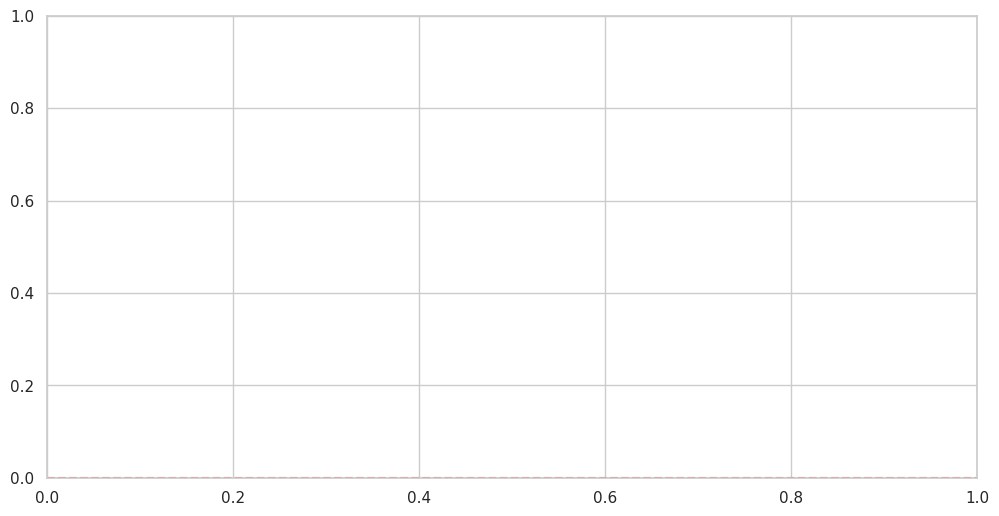

In [138]:
# Vies do modelo
plt.axhline(0, linestyle='--', color='red')

<Axes: xlabel='predictions', ylabel='error'>

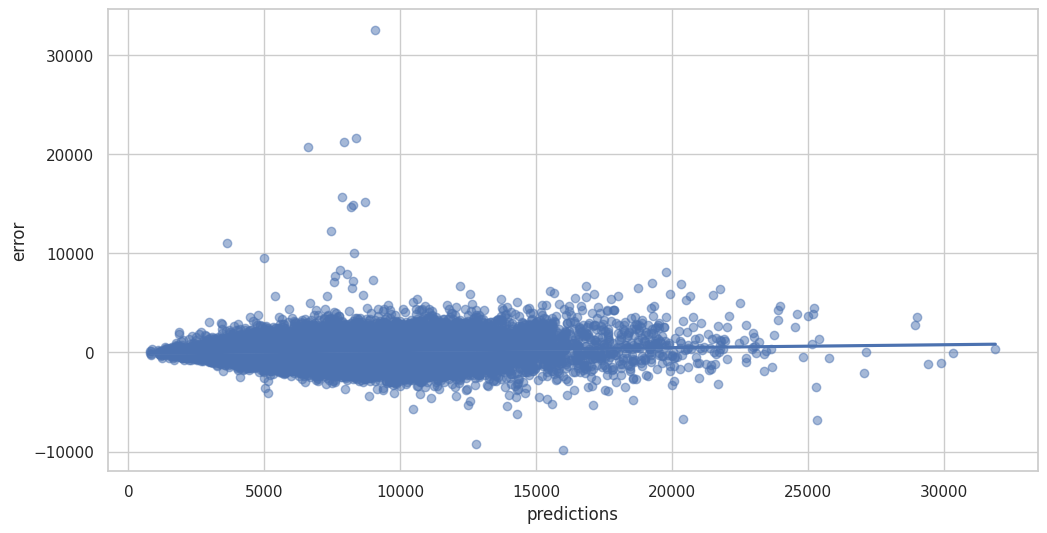

In [139]:
# avaliar heterocedasticidade
sns.regplot(x='predictions', y='error', data=df9, scatter_kws={'alpha':0.5}) 

/home/deivisson/.pyenv/versions/3.13.1/envs/rossmann/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: xlabel='error'>

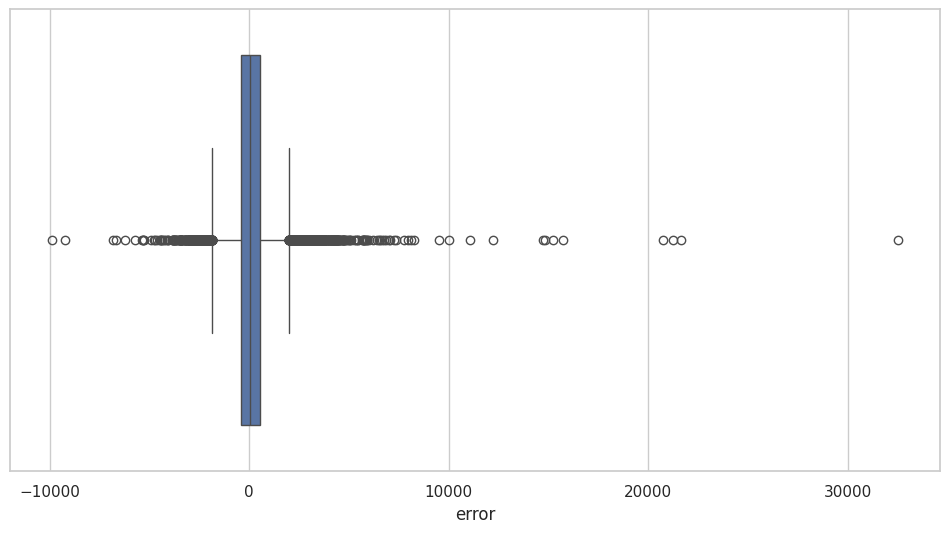

In [140]:
# outliers

sns.boxplot(x=df9['error'])

# Passo 10 - Deploy Model to Production

In [135]:
# Save Trained Model
model_path ='/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/model/model_rossmann.pkl'

with open(model_path,'wb') as file:
    pickle.dump(model_xgb_tuned, file)

## 10.1 Rossmann Class

## Renomear colunas

In [ ]:
class Rosmann (object):
    def __init__( self ):
        self.competition_distance_scaler   = pickle.load(open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/competition_distance_scaler.pkl', 'rb' ))
        self.competition_time_month_scaler = pickle.load(open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/competition_time_month_scaler.pkl', 'rb' ))
        self.promo_time_week_scaler        = pickle.load(open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/promo_time_week_scaler.pkl', 'rb' ))
        self.year_scaler                   = pickle.load(open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/year_scaler.pkl', 'rb' ))
        self.store_type_scaler             = pickle.load(open('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/parameter/store_type_scaler.pkl', 'wb' ))

    def data_cleaning (self, df1):

        # renomear colunas 

        df1 = df1.rename(columns=lambda c: re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower())
        
        # Data Types 
        df1['date'] = pd.to_datetime(df1['date'])

        # Fillout NA
        
        # =============================
        # competition_distance
        # =============================
        df1['competition_distance'] = df1['competition_distance'].fillna(200000.0)

        # =============================
        # competition_open_since_month
        # =============================
        df1['competition_open_since_month'] = df1['competition_open_since_month'].fillna(df1['date'].dt.month)

        # =============================
        # competition_open_since_year
        # =============================
        df1['competition_open_since_year'] = df1['competition_open_since_year'].fillna(df1['date'].dt.year)

        # =============================
        # promo2_since_week
        # =============================
        df1['promo2_since_week'] = df1['promo2_since_week'].fillna(df1['date'].dt.isocalendar().week)

        # =============================
        # promo2_since_year
        # =============================
        df1['promo2_since_year'] = df1['promo2_since_year'].fillna(df1['date'].dt.year)

        # =============================
        # promo_interval
        # =============================
        month_map = {
            1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
            5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
            9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
        }

        df1['promo_interval'] = df1['promo_interval'].fillna(0)
        df1['month_map'] = df1['date'].dt.month.map(month_map)

        # =============================
        # is_promo
        # =============================

        df1['is_promo'] = df1.apply(
            lambda x: 0 if x['promo_interval'] == 0 
            else 1 if x['month_map'] in x['promo_interval'].split(',') 
            else 0,
            axis=1
        )

        # Change Data Types

        # competiton
        df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
        df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)

        # promo2
        df1['promo2_since_week'] = df1['promo2_since_week'].astype( int )
        df1['promo2_since_year'] = df1['promo2_since_year'].astype( int )

        return df1
    
    def feature_engineering (self, df2):
        
        # date
        df2['year'] = df2['date'].dt.year
        df2['month'] = df2['date'].dt.month
        df2['day'] = df2['date'].dt.day
    
        # week_of_year
        df2['week_of_year'] = df2['date'].dt.isocalendar().week.astype(int)

        # year_week
        df2['year_week'] = df2['date'].dt.strftime('%Y-%W')
    
        # competition_since
        df2['competition_since'] = pd.to_datetime(
            dict(year=df2['competition_open_since_year'],
                month=df2['competition_open_since_month'],
                day=1)
        )
    
        # competition_time_month
        df2['competition_time_month'] = (
            (df2['date'] - df2['competition_since']).dt.days / 30
        ).fillna(0)

        df2['competition_time_month'] = df2['competition_time_month'].clip(lower=0).astype(int)
        
        # promo since
        df2['promo_since'] = (
            df2['promo2_since_year'].astype(str) + '-' +
            df2['promo2_since_week'].astype(str) + '-1'
        )

        df2['promo_since'] = pd.to_datetime(
            df2['promo_since'],
            format='%Y-%W-%w',
            errors='coerce'
        )
    
        # promo_time_week
        df2['promo_time_week'] = (
            (df2['date'] - df2['promo_since']) / np.timedelta64(1, 'W')
        ).fillna(0).astype(int)

        # assortment
        df2['assortment_type'] = df2['assortment'].map({
            'a':'basic','b':'extra','c':'extended'
        })

        # state holiday
        df2['state_holiday_desc'] = df2['state_holiday'].map({
            'a':'public_holiday',
            'b':'easter_holiday',
            'c':'christmas',
            '0':'regular_day'
        })
        # promo month
        df2['month_map'] = df2['date'].dt.strftime('%b')

        df2['promo_month'] = df2.apply(
            lambda x: 0 if x['promo_interval'] == 0
            else 1 if x['month_map'] in x['promo_interval']
            else 0,
        axis=1
        )

        # is promo
        df2['is_promo'] = df2['promo'] * df2['promo_month']

        # competition distance log
        df2['competition_distance_log'] = np.log1p(df2['competition_distance'])

        # Passo 03 - Filtragem de variáveis

        df2 = df2[(df2['open'] !=0) & (df2['sales']>0)]

        cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
        df2 = df2.drop( cols_drop, axis=1, errors='ignore' )

        return df2
    
    def data_preparation (self, df4):
        
        # Rescaling
        # competition distance
        df4['competition_distance'] = self.competition_distance_scaler.fit_transform( df4[['competition_distance']].values )
        
        # competition time month
        df4['competition_time_month'] = self.competition_time_month_scaler.fit_transform(df4[['competition_time_month']].values )        

        # promo time week
        df4['promo_time_week'] = self.promo_time_week_scaler.fit_transform( df4[['promo_time_week']].values )        

        # year
        df4['year'] = self.year_scaler.fit_transform( df4[['year']].values )

        # Encoding

        # state_holiday - One Hot Encoding
        df4 = pd.get_dummies( df4, prefix=['state_holiday_desc'], columns=['state_holiday'] )

        # store_type - Label Encoding        
        df4['store_type'] = self.store_type_scaler.fit_transform( df4['store_type'] )        

        # assortment - Ordinal Encoding
        assortment_dict = {'basic': 1, 'extra': 2, 'extended': 3}
        df4['assortment_type'] = df4['assortment_type'].map( assortment_dict )
        df4['sales'] = np.log1p(df4['sales'])

        # Nature Transformation
    
        # day of week (assumindo ciclo de 7 dias)
        df4['day_of_week_sin'] = np.sin(df4['day_of_week'] * (2. * np.pi / 7))
        df4['day_of_week_cos'] = np.cos(df4['day_of_week'] * (2. * np.pi / 7))

        # month (ciclo de 12 meses)
        df4['month_sin'] = np.sin(df4['month'] * (2. * np.pi / 12))
        df4['month_cos'] = np.cos(df4['month'] * (2. * np.pi / 12))

        # day (usando 30 como aproximação média para os dias do mês)
        df4['day_sin'] = np.sin(df4['day'] * (2. * np.pi / 30))
        df4['day_cos'] = np.cos(df4['day'] * (2. * np.pi / 30))

        # week of year (ciclo de 52 semanas no ano)
        df4['week_of_year_sin'] = np.sin(df4['week_of_year'] * (2. * np.pi / 52))
        df4['week_of_year_cos'] = np.cos(df4['week_of_year'] * (2. * np.pi / 52))

        selected_features = ['store', 'competition_distance', 'competition_open_since_year', 'competition_open_since_month', 'store_type', 'competition_distance_log', 'day_of_week_sin',
                             'promo2_since_week', 'assortment_type', 'promo2_since_year', 'promo_time_week', 'competition_time_month', 'promo2', 'day_of_week_cos', 'day_sin', 'day_cos', 'promo',
                             'week_of_year_cos']

        return df4[selected_features]

## 10.2 API Handler

In [ ]:
import pickle
import pandas as pd
from flask import Flask, request, Response
from rossmann.Rossmann import Rossmann

# loading model
model = pickle.load (open('/mnt/d/Onedrive/Documentos/repos/ds_em_producao/rossmann_sales/model/model_rossmann.pkl', 'rb'))

# initialize API
app = Flask ( __name__)

@app.route('/mnt/d/OneDrive/Documentos/repos/ds_em_producao/rossmann_sales/predict', methods=['POST'])

def rossmann_predict():
    test_json = request.get_json()

    if test_json: # there is data
        if isinstance (test_json, dict) : #unique example
            test_raw = pd.DataFrame(test_json, index=[0])
        
        else: # multiple example
            test_raw = pd.DataFrame(test_json, columns=test_json[0].keys())

            # Instantiate Rossmann Class
            pipeline = Rossmann()

            # data Cleaning
            df1 = pipeline.data_cleaning(test_raw)

            # feature engineering
            df2 = pipeline.feature_engineering(df1)

            # data preparation
            df3 = pipeline.data_preparation(df2)

            # prediction
            df_response = pipeline.get_prediction(model, test_raw, df3)

            return df_response

    
    else: 
        return Response ({}, status=200, mimetype='application/json')

if __name__ == '__main__':
    app.run('0.0.0.0')

## 10.3 API Tester